# Validation to datasets

In [1]:
import rioxarray as rxr
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base = Path("/home/georg/data/LEON_P5_BII")

# LUI map to LAMASUS LUM map

In [2]:
# --- load Denmark
lum = rxr.open_rasterio("/home/georg/data/LEON_P5_BII/Validation/lum_dnk_2018_3035.tif")
lui = rxr.open_rasterio("/home/georg/data/LEON_P5_BII/BII_LU_layer/Land_use_map/v7/lu_intensity_dnk_2018_v7.tif")

# # --- load Netherlands
# lui = rxr.open_rasterio(base / "BII_LU_layer/Land_use_map/v1/lu_intensity_nld_2018_v1.tif")
# lum = rxr.open_rasterio(base / "Validation/lum_nld_2018_3035.tif")


# --- align LUI → LUM grid
lui_r = lui.rio.reproject_match(lum, resampling=Resampling.nearest)

lui_arr = lui_r.squeeze().values
lum_arr = lum.squeeze().values



In [3]:
OK = {
    230:[25], 231:[25], 232:[25],
    220:[2],  221:[3],  222:[3],
    210:[2],  211:[3],  212:[3],
    30:[4],   31:[4],   32:[5],
    70:[11],  71:[10],  72:[10],
    60:[18],  61:[17],  62:[16],
    10:[29],  11:[28],  12:[27],
}
valid_lui_codes = set(OK.keys())

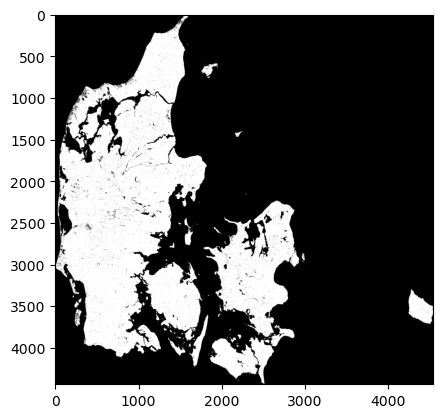

In [5]:
INVALID_LUI = [0, 255, 240, 241, 242]

valid = np.isin(lui_arr, list(valid_lui_codes))

plt.imshow(valid, cmap="gray")

In [6]:
match = np.zeros_like(lui_arr, dtype=bool)

for k, vals in OK.items():
    match |= ((lui_arr == k) & np.isin(lum_arr, vals))

overall_acc = match[valid].sum() / valid.sum()

print("NLD agreement:", f"{overall_acc:.2%}")

NLD agreement: 5.92%


In [6]:
print("\nConfusion counts (LUI_class → LUM_value : count):")
for k, vals in OK.items():
    mask = (lui_arr == k) & valid
    unique, counts = np.unique(lum_arr[mask], return_counts=True)
    print(k, dict(zip(unique, counts)))


Confusion counts (LUI_class → LUM_value : count):
230 {2: 140, 3: 561, 4: 260, 5: 3, 7: 98, 8: 11, 12: 1, 15: 1, 16: 1, 18: 2, 19: 2, 20: 33, 21: 26, 22: 20, 25: 4, 26: 23, 28: 3, 29: 91, 30: 5, 32: 209, 255: 25}
231 {2: 454, 3: 2707, 4: 2044, 5: 35, 7: 1290, 8: 193, 12: 11, 13: 2, 15: 55, 16: 146, 17: 8, 18: 10, 19: 228, 20: 533, 21: 504, 22: 188, 25: 31, 26: 354, 27: 6, 28: 39, 29: 669, 30: 60, 31: 22, 32: 1000, 255: 49}
232 {2: 692, 3: 4968, 4: 4584, 5: 36, 7: 12055, 8: 2344, 9: 2, 10: 92, 11: 3, 12: 17, 13: 1, 15: 799, 16: 1025, 17: 144, 18: 252, 19: 2396, 20: 4237, 21: 3085, 22: 826, 25: 270, 26: 1213, 27: 60, 28: 221, 29: 2156, 30: 362, 31: 103, 32: 3764, 33: 11, 255: 147}
220 {2: 639, 3: 2914, 4: 1281, 5: 7, 7: 316, 8: 39, 12: 4, 15: 10, 16: 7, 17: 1, 18: 4, 19: 5, 20: 75, 21: 58, 22: 53, 25: 6, 26: 91, 27: 2, 28: 4, 29: 276, 30: 11, 31: 1, 32: 397, 255: 50}
221 {2: 1773, 3: 11538, 4: 7812, 5: 144, 7: 3306, 8: 520, 9: 1, 10: 10, 11: 1, 12: 23, 13: 5, 15: 157, 16: 327, 17: 34, 1

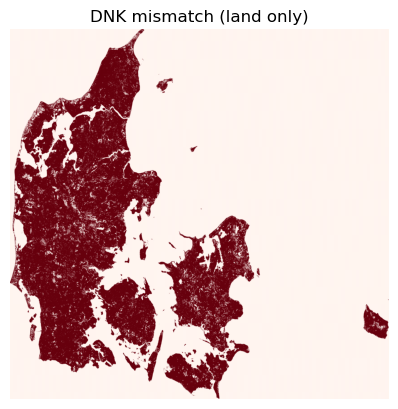

In [7]:
mismatch = (valid & (~match)).astype("uint8")

# add band dimension
mismatch3d = mismatch[np.newaxis, :, :]

# write raster
mismatch_da = lum.copy(data=mismatch3d)
mismatch_da.rio.to_raster("DNK_LUI_LUM_mismatch_landonly.tif")

# quick visualization
plt.imshow(mismatch, cmap="Reds")
plt.title("DNK mismatch (land only)")
plt.axis("off")
plt.show()

## Simple sub-class category

In [7]:
LUM_GROUP = {
    25:"Grassland",
    2:"Forest-light",
    3:"Forest-med",
    4:"Plantation-min",
    5:"Plantation-int",
    11:"Crop-light",
    10:"Crop-min",
    12:"Crop-int",
    18:"Pasture-min",
    17:"Pasture-light",
    16:"Pasture-int",
    29:"Urban-min",
    28:"Urban-light",
    27:"Urban-int",
}


In [8]:
lum_simple = np.full_like(lum_arr, fill_value=-1)   # -1 = Other

for lum_val, name in LUM_GROUP.items():
    lum_simple[lum_arr == lum_val] = lum_val

In [9]:
LUI_GROUP = {
    230:"SV-young",
    231:"SV-young",
    232:"SV-young",
    220:"SV-intermed-min",
    221:"SV-intermed-light",
    222:"SV-intermed-int",
    210:"SV-mature-min",
    211:"SV-mature-light",
    212:"SV-mature-int",
    30:"Plantation-min",
    31:"Plantation-light",
    32:"Plantation-int",
    70:"Cropland-min",
    71:"Cropland-light",
    72:"Cropland-int",
    60:"Pasture-min",
    61:"Pasture-light",
    62:"Pasture-int",
    10:"Urban-min",
    11:"Urban-light",
    12:"Urban-int"
}

In [10]:
# Map LUI and LUM to their groups, using "Other" for unmapped values

lui_groups = np.vectorize(LUI_GROUP.get)(lui_arr, "Other")
lum_groups = np.vectorize(LUM_GROUP.get)(lum_simple, "Other")

unique_lui = sorted(set(lui_groups.flatten()) - {"Other"})
unique_lum = sorted(set(lum_groups.flatten()) - {"Other"})

conf = np.zeros((len(unique_lui), len(unique_lum)), dtype=int)

for i, lg in enumerate(unique_lui):
    for j, mg in enumerate(unique_lum):
        conf[i,j] = np.sum((lui_groups == lg) & (lum_groups == mg))


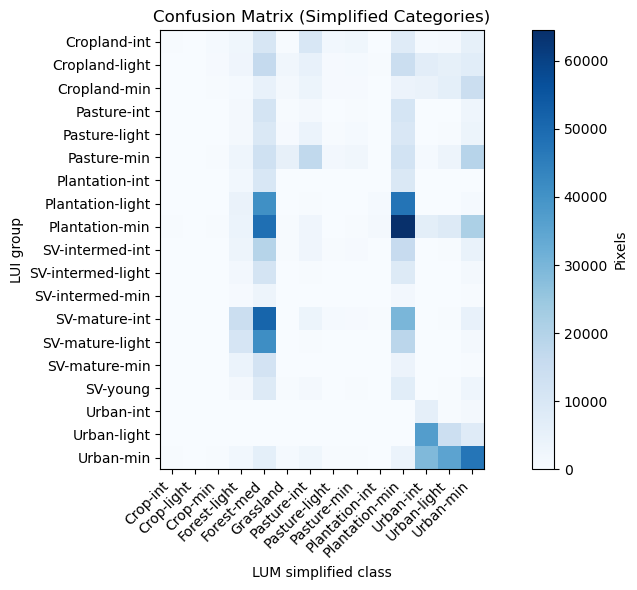

In [11]:
plt.figure(figsize=(10,6))
plt.imshow(conf, cmap="Blues")
plt.colorbar(label="Pixels")
plt.xticks(range(len(unique_lum)), unique_lum, rotation=45, ha='right')
plt.yticks(range(len(unique_lui)), unique_lui)
plt.xlabel("LUM simplified class")
plt.ylabel("LUI group")
plt.title("Confusion Matrix (Simplified Categories)")
plt.tight_layout()
plt.show()

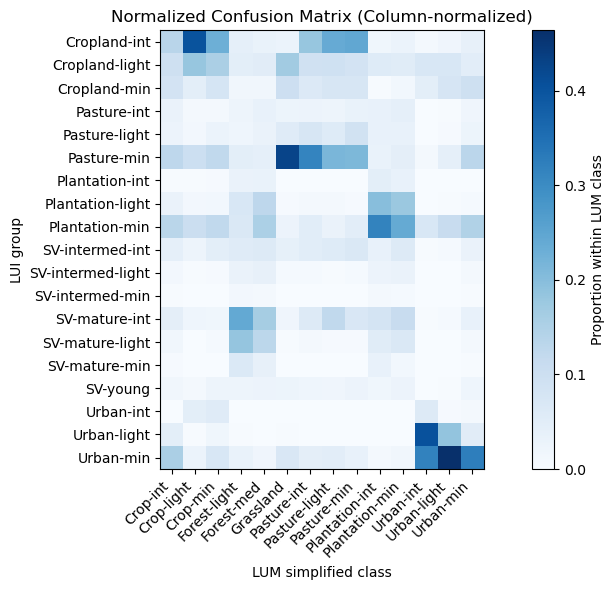

In [12]:
conf_norm = conf / conf.sum(axis=0, keepdims=True)

plt.figure(figsize=(10,6))
plt.imshow(conf_norm, cmap="Blues")
plt.colorbar(label="Proportion within LUM class")
plt.xticks(range(len(unique_lum)), unique_lum, rotation=45, ha='right')
plt.yticks(range(len(unique_lui)), unique_lui)
plt.xlabel("LUM simplified class")
plt.ylabel("LUI group")
plt.title("Normalized Confusion Matrix (Column-normalized)")
plt.tight_layout()
plt.show()

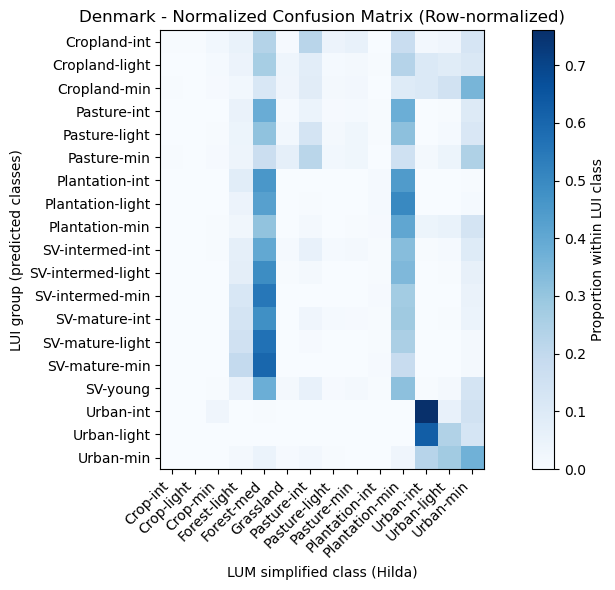

In [13]:
conf_norm = conf / conf.sum(axis=1, keepdims=True)   # row-normalised

plt.figure(figsize=(10,6))
plt.imshow(conf_norm, cmap="Blues")
plt.colorbar(label="Proportion within LUI class")  # optional: reflect row-normalised meaning
plt.xticks(range(len(unique_lum)), unique_lum, rotation=45, ha='right')
plt.yticks(range(len(unique_lui)), unique_lui)
plt.xlabel("LUM simplified class (Hilda)")
plt.ylabel("LUI group (predicted classes)")
plt.title("Denmark - Normalized Confusion Matrix (Row-normalized)")
plt.tight_layout()
plt.show()

In [ ]:
# # === LEVEL 1: Broad land use type (5 classes) ===
# LUI_BROAD = {
#     'Cropland-int': 'Cropland', 'Cropland-light': 'Cropland', 'Cropland-min': 'Cropland',
#     'Pasture-int': 'Pasture', 'Pasture-light': 'Pasture', 'Pasture-min': 'Pasture',
#     'Plantation-int': 'Plantation', 'Plantation-light': 'Plantation', 'Plantation-min': 'Plantation',
#     'SV-intermed-int': 'Forest/SV', 'SV-intermed-light': 'Forest/SV', 'SV-intermed-min': 'Forest/SV',
#     'SV-mature-int': 'Forest/SV', 'SV-mature-light': 'Forest/SV', 'SV-mature-min': 'Forest/SV',
#     'SV-young': 'Forest/SV',
#     'Urban-int': 'Urban', 'Urban-light': 'Urban', 'Urban-min': 'Urban',
# }

# LUM_BROAD = {
#     'Crop-int': 'Cropland', 'Crop-light': 'Cropland', 'Crop-min': 'Cropland',
#     'Forest-light': 'Forest/SV', 'Forest-med': 'Forest/SV',
#     'Grassland': 'Pasture',
#     'Pasture-int': 'Pasture', 'Pasture-light': 'Pasture', 'Pasture-min': 'Pasture',
#     'Plantation-int': 'Plantation', 'Plantation-min': 'Plantation',
#     'Urban-int': 'Urban', 'Urban-light': 'Urban', 'Urban-min': 'Urban',
# }

# # === LEVEL 2: Intensity only (3 classes, ignoring land use type) ===
# LUI_INTENSITY = {
#     'Cropland-int': 'Intensive', 'Cropland-light': 'Light', 'Cropland-min': 'Minimal',
#     'Pasture-int': 'Intensive', 'Pasture-light': 'Light', 'Pasture-min': 'Minimal',
#     'Plantation-int': 'Intensive', 'Plantation-light': 'Light', 'Plantation-min': 'Minimal',
#     'SV-intermed-int': 'Intensive', 'SV-intermed-light': 'Light', 'SV-intermed-min': 'Minimal',
#     'SV-mature-int': 'Intensive', 'SV-mature-light': 'Light', 'SV-mature-min': 'Minimal',
#     'SV-young': 'Minimal',
#     'Urban-int': 'Intensive', 'Urban-light': 'Light', 'Urban-min': 'Minimal',
# }

# LUM_INTENSITY = {
#     'Crop-int': 'Intensive', 'Crop-light': 'Light', 'Crop-min': 'Minimal',
#     'Forest-light': 'Light', 'Forest-med': 'Light',
#     'Grassland': 'Light',  # no explicit intensity; treat as moderate
#     'Pasture-int': 'Intensive', 'Pasture-light': 'Light', 'Pasture-min': 'Minimal',
#     'Plantation-int': 'Intensive', 'Plantation-min': 'Minimal',
#     'Urban-int': 'Intensive', 'Urban-light': 'Light', 'Urban-min': 'Minimal',
# }


# def regroup_confusion(conf, row_labels, col_labels, row_map, col_map):
#     """Aggregate confusion matrix into new groupings."""
#     new_row = [row_map[l] for l in row_labels]
#     new_col = [col_map[l] for l in col_labels]
#     shared_classes = sorted(set(new_row) & set(new_col))
    
#     n = len(shared_classes)
#     cm_new = np.zeros((n, n), dtype=int)
    
#     for i, rl in enumerate(row_labels):
#         for j, cl in enumerate(col_labels):
#             rg = row_map[rl]
#             cg = col_map[cl]
#             if rg in shared_classes and cg in shared_classes:
#                 ri = shared_classes.index(rg)
#                 ci = shared_classes.index(cg)
#                 cm_new[ri, ci] += conf[i, j]
    
#     return cm_new, shared_classes


# # --- Broad land use type ---
# cm_broad, labels_broad = regroup_confusion(conf, unique_lui, unique_lum, LUI_BROAD, LUM_BROAD)
# stats_broad = confusion_stats(cm_broad, labels_broad)

# print("=== BROAD LAND USE TYPE ===")
# for k, v in stats_broad.items():
#     print(k, ":", v)

# ref_b = cm_broad.sum(axis=0)
# pred_b = cm_broad.sum(axis=1)
# print("\nReference (LAMASUS):", dict(zip(labels_broad, ref_b)))
# print("Predicted (LUI):   ", dict(zip(labels_broad, pred_b)))
# print("Prevalence (%):", dict(zip(labels_broad, np.round(100 * ref_b / cm_broad.sum(), 1))))

# cm_broad_norm = cm_broad / cm_broad.sum(axis=1, keepdims=True)
# print("\nRow-normalised:\n", np.round(cm_broad_norm, 2))


# # --- Intensity level ---
# cm_int, labels_int = regroup_confusion(conf, unique_lui, unique_lum, LUI_INTENSITY, LUM_INTENSITY)
# stats_int = confusion_stats(cm_int, labels_int)

# print("\n=== INTENSITY LEVEL ===")
# for k, v in stats_int.items():
#     print(k, ":", v)

# ref_i = cm_int.sum(axis=0)
# pred_i = cm_int.sum(axis=1)
# print("\nReference (LAMASUS):", dict(zip(labels_int, ref_i)))
# print("Predicted (LUI):   ", dict(zip(labels_int, pred_i)))
# print("Prevalence (%):", dict(zip(labels_int, np.round(100 * ref_i / cm_int.sum(), 1))))

# cm_int_norm = cm_int / cm_int.sum(axis=1, keepdims=True)
# print("\nRow-normalised:\n", np.round(cm_int_norm, 2))

=== BROAD LAND USE TYPE ===
Overall accuracy : 0.459475847477659
Balanced accuracy : 0.47581404240548136
Kappa : 0.30828694023722264
Per-class precision : {'Cropland': 0.45714285714285713, 'Forest/SV': 0.23411520697351024, 'Pasture': 0.43621668753019227, 'Plantation': 0.6686180865814204, 'Urban': 0.709119596406764}
Per-class recall : {'Cropland': 0.006383302624188307, 'Forest/SV': 0.9016360249453309, 'Pasture': 0.9218506039937546, 'Plantation': 0.027354349120910636, 'Urban': 0.5218459313432224}
Per-class F1 : {'Cropland': 0.012590794017301989, 'Forest/SV': 0.37171292209513196, 'Pasture': 0.592204258775158, 'Plantation': 0.05255843947453671, 'Urban': 0.6012372692467087}

Reference (LAMASUS): {'Cropland': 2660, 'Forest/SV': 380411, 'Pasture': 668631, 'Plantation': 12982, 'Urban': 394853}
Predicted (LUI):    {'Cropland': 190497, 'Forest/SV': 98776, 'Pasture': 316394, 'Plantation': 317317, 'Urban': 536553}
Prevalence (%): {'Cropland': 0.2, 'Forest/SV': 26.1, 'Pasture': 45.8, 'Plantation': 

In [14]:
import numpy as np

# ============================================================
# STEP 1: Corrected LAMASUS class mapping (from official legend)
# ============================================================
LUM_GROUP_FULL = {
    # Forest
    1:  "Forest-min",        # Primary forest
    2:  "Forest-light",      # Close-to-nature management
    3:  "Forest-med",        # Combined objective forestry
    4:  "Plantation-min",    # Intensive forestry
    5:  "Plantation-int",    # Very intensive forestry
    # Cropland
    6:  "Crop-int",          # Irrigated arable cropland
    7:  "Crop-int",          # Rainfed intensive arable cropland
    8:  "Crop-min",          # Rainfed extensive arable cropland
    9:  "Crop-int",          # Irrigated permanent cropland
    10: "Crop-light",        # Rainfed intensive permanent cropland
    11: "Crop-min",          # Rainfed extensive permanent cropland
    14: "Crop-light",        # Agroforestry
    # Grassland / Pasture
    15: "Pasture-int",       # Very high density managed pasture
    16: "Pasture-int",       # High density managed pasture
    17: "Pasture-light",     # Moderate density managed pasture
    18: "Pasture-min",       # Low density managed pasture
    19: "Pasture-int",       # Very high density managed grassland (mown)
    20: "Pasture-int",       # High density managed grassland (mown)
    21: "Pasture-light",     # Moderate density managed grassland (mown)
    22: "Pasture-min",       # Low density managed grassland (mown)
    23: "Pasture-min",       # Rough grazing
    24: "Pasture-light",     # Silvo-pastoral agroforestry
    25: "Pasture-min",       # Managed semi-natural and natural grassland
    26: "Pasture-min",       # Unmanaged semi-natural and natural grassland
    # Urban
    27: "Urban-int",         # High intensity urban
    28: "Urban-light",       # Medium intensity urban
    29: "Urban-min",         # Low intensity urban
    30: "Urban-light",       # Infrastructure
    31: "Urban-min",         # Other urban
}

# LUI mapping (unchanged)
LUI_GROUP = {
    230:"SV-young", 231:"SV-young", 232:"SV-young",
    220:"SV-intermed-min", 221:"SV-intermed-light", 222:"SV-intermed-int",
    210:"SV-mature-min", 211:"SV-mature-light", 212:"SV-mature-int",
    30:"Plantation-min", 31:"Plantation-light", 32:"Plantation-int",
    70:"Cropland-min", 71:"Cropland-light", 72:"Cropland-int",
    60:"Pasture-min", 61:"Pasture-light", 62:"Pasture-int",
    10:"Urban-min", 11:"Urban-light", 12:"Urban-int",
}

# ============================================================
# STEP 2: Rebuild groups and confusion matrix
# ============================================================
lum_simple = np.full_like(lum_arr, fill_value=-1)
for lum_val in LUM_GROUP_FULL:
    lum_simple[lum_arr == lum_val] = lum_val

lum_groups = np.vectorize(LUM_GROUP_FULL.get)(lum_simple, "Other")
lui_groups = np.vectorize(LUI_GROUP.get)(lui_arr, "Other")

unique_lui = sorted(set(lui_groups.flatten()) - {"Other"})
unique_lum = sorted(set(lum_groups.flatten()) - {"Other"})

conf = np.zeros((len(unique_lui), len(unique_lum)), dtype=int)
for i, lg in enumerate(unique_lui):
    for j, mg in enumerate(unique_lum):
        conf[i,j] = np.sum((lui_groups == lg) & (lum_groups == mg))

# Coverage check
both_valid = np.sum((lui_groups != "Other") & (lum_groups != "Other"))
lum_other = np.sum((lum_groups == "Other") & (lum_arr > 0) & (lum_arr != 255))
print(f"Pixels in confusion matrix: {both_valid:,}")
print(f"LAMASUS pixels still unmapped (excl. 255): {lum_other:,}")
print(f"LUI classes: {unique_lui}")
print(f"LUM classes: {unique_lum}")
print(f"Confusion matrix shape: {conf.shape}")

# ============================================================
# STEP 3: Stats function
# ============================================================
def confusion_stats(cm, labels):
    diag = np.diag(cm)
    total = cm.sum()
    oa = diag.sum() / total if total > 0 else np.nan
    recall = diag / cm.sum(axis=1)
    precision = diag / cm.sum(axis=0)
    f1 = 2 * (precision * recall) / (precision + recall)
    bal_acc = np.nanmean(recall)
    row_marg = cm.sum(axis=1)
    col_marg = cm.sum(axis=0)
    expected = (row_marg * col_marg).sum() / (total * total)
    kappa = (oa - expected) / (1 - expected) if expected < 1 else np.nan
    return {
        "Overall accuracy": oa,
        "Balanced accuracy": bal_acc,
        "Kappa": kappa,
        "Per-class precision": dict(zip(labels, precision)),
        "Per-class recall": dict(zip(labels, recall)),
        "Per-class F1": dict(zip(labels, f1)),
    }

# ============================================================
# STEP 4: Regrouping maps (updated for new classes)
# ============================================================
LUI_BROAD = {
    'Cropland-int': 'Cropland', 'Cropland-light': 'Cropland', 'Cropland-min': 'Cropland',
    'Pasture-int': 'Pasture', 'Pasture-light': 'Pasture', 'Pasture-min': 'Pasture',
    'Plantation-int': 'Plantation', 'Plantation-light': 'Plantation', 'Plantation-min': 'Plantation',
    'SV-intermed-int': 'Forest/SV', 'SV-intermed-light': 'Forest/SV', 'SV-intermed-min': 'Forest/SV',
    'SV-mature-int': 'Forest/SV', 'SV-mature-light': 'Forest/SV', 'SV-mature-min': 'Forest/SV',
    'SV-young': 'Forest/SV',
    'Urban-int': 'Urban', 'Urban-light': 'Urban', 'Urban-min': 'Urban',
}

LUM_BROAD = {
    'Crop-int': 'Cropland', 'Crop-light': 'Cropland', 'Crop-min': 'Cropland',
    'Forest-min': 'Forest/SV', 'Forest-light': 'Forest/SV', 'Forest-med': 'Forest/SV',
    'Pasture-int': 'Pasture', 'Pasture-light': 'Pasture', 'Pasture-min': 'Pasture',
    'Plantation-int': 'Plantation', 'Plantation-min': 'Plantation',
    'Urban-int': 'Urban', 'Urban-light': 'Urban', 'Urban-min': 'Urban',
}

LUI_INTENSITY = {
    'Cropland-int': 'Intensive', 'Cropland-light': 'Light', 'Cropland-min': 'Minimal',
    'Pasture-int': 'Intensive', 'Pasture-light': 'Light', 'Pasture-min': 'Minimal',
    'Plantation-int': 'Intensive', 'Plantation-light': 'Light', 'Plantation-min': 'Minimal',
    'SV-intermed-int': 'Intensive', 'SV-intermed-light': 'Light', 'SV-intermed-min': 'Minimal',
    'SV-mature-int': 'Intensive', 'SV-mature-light': 'Light', 'SV-mature-min': 'Minimal',
    'SV-young': 'Minimal',
    'Urban-int': 'Intensive', 'Urban-light': 'Light', 'Urban-min': 'Minimal',
}

LUM_INTENSITY = {
    'Crop-int': 'Intensive', 'Crop-light': 'Light', 'Crop-min': 'Minimal',
    'Forest-min': 'Minimal', 'Forest-light': 'Light', 'Forest-med': 'Light',
    'Pasture-int': 'Intensive', 'Pasture-light': 'Light', 'Pasture-min': 'Minimal',
    'Plantation-int': 'Intensive', 'Plantation-min': 'Minimal',
    'Urban-int': 'Intensive', 'Urban-light': 'Light', 'Urban-min': 'Minimal',
}

# ============================================================
# STEP 5: Regroup and compute
# ============================================================
def regroup_confusion(conf, row_labels, col_labels, row_map, col_map):
    new_row = [row_map[l] for l in row_labels]
    new_col = [col_map[l] for l in col_labels]
    shared_classes = sorted(set(new_row) & set(new_col))
    n = len(shared_classes)
    cm_new = np.zeros((n, n), dtype=int)
    for i, rl in enumerate(row_labels):
        for j, cl in enumerate(col_labels):
            rg = row_map[rl]
            cg = col_map[cl]
            if rg in shared_classes and cg in shared_classes:
                ri = shared_classes.index(rg)
                ci = shared_classes.index(cg)
                cm_new[ri, ci] += conf[i, j]
    return cm_new, shared_classes

# --- Broad land use type ---
cm_broad, labels_broad = regroup_confusion(conf, unique_lui, unique_lum, LUI_BROAD, LUM_BROAD)
stats_broad = confusion_stats(cm_broad, labels_broad)

print("\n=== BROAD LAND USE TYPE ===")
for k, v in stats_broad.items():
    print(k, ":", v)

ref_b = cm_broad.sum(axis=0)
pred_b = cm_broad.sum(axis=1)
print("\nReference (LAMASUS):", dict(zip(labels_broad, ref_b)))
print("Predicted (LUI):   ", dict(zip(labels_broad, pred_b)))
print("Prevalence (%):", dict(zip(labels_broad, np.round(100 * ref_b / cm_broad.sum(), 1))))

cm_broad_norm = cm_broad / cm_broad.sum(axis=1, keepdims=True)
print("\nRow-normalised:\n", np.round(cm_broad_norm, 2))

# --- Intensity level ---
cm_int, labels_int = regroup_confusion(conf, unique_lui, unique_lum, LUI_INTENSITY, LUM_INTENSITY)
stats_int = confusion_stats(cm_int, labels_int)

print("\n=== INTENSITY LEVEL ===")
for k, v in stats_int.items():
    print(k, ":", v)

ref_i = cm_int.sum(axis=0)
pred_i = cm_int.sum(axis=1)
print("\nReference (LAMASUS):", dict(zip(labels_int, ref_i)))
print("Predicted (LUI):   ", dict(zip(labels_int, pred_i)))
print("Prevalence (%):", dict(zip(labels_int, np.round(100 * ref_i / cm_int.sum(), 1))))

cm_int_norm = cm_int / cm_int.sum(axis=1, keepdims=True)
print("\nRow-normalised:\n", np.round(cm_int_norm, 2))

Pixels in confusion matrix: 5,117,911
LAMASUS pixels still unmapped (excl. 255): 650,860
LUI classes: ['Cropland-int', 'Cropland-light', 'Cropland-min', 'Pasture-int', 'Pasture-light', 'Pasture-min', 'Plantation-int', 'Plantation-light', 'Plantation-min', 'SV-intermed-int', 'SV-intermed-light', 'SV-intermed-min', 'SV-mature-int', 'SV-mature-light', 'SV-mature-min', 'SV-young', 'Urban-int', 'Urban-light', 'Urban-min']
LUM classes: ['Crop-int', 'Crop-light', 'Crop-min', 'Forest-light', 'Forest-med', 'Forest-min', 'Pasture-int', 'Pasture-light', 'Pasture-min', 'Plantation-int', 'Plantation-min', 'Urban-int', 'Urban-light', 'Urban-min']
Confusion matrix shape: (19, 14)

=== BROAD LAND USE TYPE ===
Overall accuracy : 0.6618489457905774
Balanced accuracy : 0.4782190168319511
Kappa : 0.4153424390095479
Per-class precision : {'Cropland': 0.7739715937413973, 'Forest/SV': 0.48497706788119993, 'Pasture': 0.33487645960164814, 'Plantation': 0.4553781790157437, 'Urban': 0.6013765920522399}
Per-class

# LUI to Hilda LU

In [15]:
# --- load Denmark
lui_dnk = rxr.open_rasterio("/home/georg/data/LEON_P5_BII/BII_LU_layer/Land_use_map/v7/lu_intensity_dnk_2018_v7.tif")
lu_hilda_dnk = rxr.open_rasterio(base / "Validation/lu_hilda_dnk_2018_3035.tif") 

# --- load Netherlands
lui_nld = rxr.open_rasterio(base / "BII_LU_layer/Land_use_map/v7/lu_intensity_nld_2018_v7.tif")
lu_hilda_nld = rxr.open_rasterio(base / "Validation/lu_hilda_nld_2018_3035.tif") 


# --- align LUI → LU Hilda grid
lui_dnk_r = lui_dnk.rio.reproject_match(lu_hilda_dnk, resampling=Resampling.nearest)
lui_nld_r = lui_nld.rio.reproject_match(lu_hilda_nld, resampling=Resampling.nearest)


lui_own_dnk_arr = lui_dnk_r.squeeze().values
lu_hilda_dnk_arr = lu_hilda_dnk.squeeze().values

lui_own_nld_arr = lui_nld_r.squeeze().values
lu_hilda_nld_arr = lu_hilda_nld.squeeze().values

In [16]:
LU_hilda_GROUP = {
    1:"Primary vegetation - minimal",
    2:"Primary vegetation",
    3:"Secondary vegetation",
    4:"Cropland",
    5:"Urban",
    6:"Pasture",
    7:"Plantation/Agroforestry",
}

In [17]:
LUI_GROUP = {
    230:"SV-young",
    231:"SV-young",
    232:"SV-young",
    220:"SV-intermed-min",
    221:"SV-intermed-light",
    222:"SV-intermed-int",
    210:"SV-mature-min",
    211:"SV-mature-light",
    212:"SV-mature-int",
    30:"Plantation-min",
    31:"Plantation-light",
    32:"Plantation-int",
    70:"Cropland-min",
    71:"Cropland-light",
    72:"Cropland-int",
    60:"Pasture-min",
    61:"Pasture-light",
    62:"Pasture-int",
    10:"Urban-min",
    11:"Urban-light",
    12:"Urban-int"
}

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix

# ---------- 1) Define mappings ----------
HILDA_TO_COARSE = {
    3: "SV",
    7: "Plantation",
    5: "Urban",
    4: "Cropland",
    6: "Pasture",
}

LUI_TO_COARSE = {
    # SV
    230:"SV", 231:"SV", 232:"SV",
    220:"SV", 221:"SV", 222:"SV",
    210:"SV", 211:"SV", 212:"SV",

    # Plantation
    30:"Plantation", 31:"Plantation", 32:"Plantation",

    # Cropland
    70:"Cropland", 71:"Cropland", 72:"Cropland",

    # Pasture
    60:"Pasture", 61:"Pasture", 62:"Pasture",

    # Urban
    10:"Urban", 11:"Urban", 12:"Urban",
}

COARSE_LABELS = ["SV", "Plantation", "Urban", "Cropland", "Pasture"]


def arrays_to_coarse_pairs(lui_arr, hilda_arr):
    lui_f = lui_arr.ravel()
    hil_f = hilda_arr.ravel()

    # Valid pixels = both are in dictionary keys
    mask = np.isin(lui_f, list(LUI_TO_COARSE.keys())) & \
           np.isin(hil_f, list(HILDA_TO_COARSE.keys()))

    lui_coarse = np.array([LUI_TO_COARSE[int(v)] for v in lui_f[mask]])
    hilda_coarse = np.array([HILDA_TO_COARSE[int(v)] for v in hil_f[mask]])

    return lui_coarse, hilda_coarse


def compute_confusions(lui_arr, hilda_arr, labels=COARSE_LABELS):
    """
    Confusion matrix where:
        rows   = LUI (your prediction)
        cols   = Hilda (reference)
    """
    y_lui, y_hilda = arrays_to_coarse_pairs(lui_arr, hilda_arr)

    # IMPORTANT: predicted first, reference second
    cm = confusion_matrix(y_lui, y_hilda, labels=labels)

    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    return cm, cm_norm, labels


def pretty_print_cm(cm, labels, title="Confusion matrix"):
    print(f"\n{title} (rows = LUI, cols = Hilda/reference)")
    header = ["{:>12}".format("")] + ["{:>12}".format(lbl) for lbl in labels]
    print("".join(header))
    for i, row in enumerate(cm):
        row_str = ["{:>12}".format(labels[i])] + ["{:>12}".format(x) for x in row]
        print("".join(row_str))


# ---------- 2) Denmark ----------
cm_d, cmn_d, labels = compute_confusions(lui_own_dnk_arr, lu_hilda_dnk_arr)
pretty_print_cm(cm_d, labels, "Denmark - counts")
pretty_print_cm(np.round(cmn_d, 3), labels, "Denmark - normalized")

# ---------- 3) Netherlands ----------
cm_n, cmn_n, labels = compute_confusions(lui_own_nld_arr, lu_hilda_nld_arr)
pretty_print_cm(cm_n, labels, "Netherlands - counts")
pretty_print_cm(np.round(cmn_n, 3), labels, "Netherlands - normalized")



Denmark - counts (rows = LUI, cols = Hilda/reference)
                      SV  Plantation       Urban    Cropland     Pasture
          SV       15257         121        3102       24776        2005
  Plantation       14696         117        3256       18580        1414
       Urban        4840         151       16776       15091        1997
    Cropland       22670        1471       17797      210304       10246
     Pasture       10114         323        3486       42146       10872

Denmark - normalized (rows = LUI, cols = Hilda/reference)
                      SV  Plantation       Urban    Cropland     Pasture
          SV       0.337       0.003       0.069       0.547       0.044
  Plantation       0.386       0.003       0.086       0.488       0.037
       Urban       0.125       0.004       0.432       0.388       0.051
    Cropland       0.086       0.006       0.068       0.801       0.039
     Pasture       0.151       0.005       0.052        0.63       0.162

Netherlan

In [19]:
import numpy as np

def confusion_stats(cm, labels):
    """
    Given confusion matrix (rows=LUI predicted, cols=Hilda reference),
    return accuracy stats in a dictionary.
    """

    # Total correct
    diag = np.diag(cm)
    total = cm.sum()

    # Overall accuracy
    oa = diag.sum() / total if total > 0 else np.nan

    # Per-class recall (Producer's accuracy): TP / (TP + FN)
    recall = diag / cm.sum(axis=1)

    # Per-class precision (User's accuracy): TP / (TP + FP)
    precision = diag / cm.sum(axis=0)

    # F1 score
    f1 = 2 * (precision * recall) / (precision + recall)

    # Balanced accuracy (mean recall)
    bal_acc = np.nanmean(recall)

    # Cohen’s kappa
    row_marg = cm.sum(axis=1)
    col_marg = cm.sum(axis=0)
    expected = (row_marg * col_marg).sum() / (total * total)
    kappa = (oa - expected) / (1 - expected) if expected < 1 else np.nan

    return {
        "Overall accuracy": oa,
        "Balanced accuracy": bal_acc,
        "Kappa": kappa,
        "Per-class precision": dict(zip(labels, precision)),
        "Per-class recall": dict(zip(labels, recall)),
        "Per-class F1": dict(zip(labels, f1)),
    }

# ---- Denmark ----
stats_dnk = confusion_stats(cm_d, labels)
print("\nDenmark stats:")
for k, v in stats_dnk.items():
    print(k, ":", v)

# ---- Netherlands ----
stats_nld = confusion_stats(cm_n, labels)
print("\nNetherlands stats:")
for k, v in stats_nld.items():
    print(k, ":", v)


Denmark stats:
Overall accuracy : 0.5609422330871021
Balanced accuracy : 0.34710573583930876
Kappa : 0.22604788202794507
Per-class precision : {'SV': 0.22577208221732245, 'Plantation': 0.053595968850206135, 'Urban': 0.37769322556678747, 'Cropland': 0.6764426803732426, 'Pasture': 0.4097384487826939}
Per-class recall : {'SV': 0.33708932635160516, 'Plantation': 0.00307385124661745, 'Urban': 0.4317591043623729, 'Cropland': 0.8011947212824967, 'Pasture': 0.16241167595345155}
Per-class F1 : {'SV': 0.2704230844219146, 'Plantation': 0.00581424240918352, 'Urban': 0.40292054952445, 'Cropland': 0.7335524996293938, 'Pasture': 0.2326183471516448}

Netherlands stats:
Overall accuracy : 0.4695922252279331
Balanced accuracy : 0.38644099156991657
Kappa : 0.2683944648492183
Per-class precision : {'SV': 0.2412289182511548, 'Plantation': 0.056345733041575495, 'Urban': 0.5531321133245026, 'Cropland': 0.503682081696369, 'Pasture': 0.4556772627180848}
Per-class recall : {'SV': 0.42060310919647875, 'Plantati

In [20]:
# Class support counts (number of reference pixels per class)
# Columns = HILDA reference classes
ref_counts_d = cm_d.sum(axis=0)  # sum down rows → total per reference class
pred_counts_d = cm_d.sum(axis=1)  # sum across cols → total per predicted class

ref_counts_n = cm_n.sum(axis=0)
pred_counts_n = cm_n.sum(axis=1)

print("\nDenmark class support:")
print("Reference (HILDA):", dict(zip(labels, ref_counts_d)))
print("Predicted (LUI):  ", dict(zip(labels, pred_counts_d)))
print("Total pixels:     ", cm_d.sum())

print("\nNetherlands class support:")
print("Reference (HILDA):", dict(zip(labels, ref_counts_n)))
print("Predicted (LUI):  ", dict(zip(labels, pred_counts_n)))
print("Total pixels:     ", cm_n.sum())

# Percentage of landscape per reference class
print("\nDenmark class prevalence (%):")
print(dict(zip(labels, np.round(100 * ref_counts_d / cm_d.sum(), 1))))
print("\nNetherlands class prevalence (%):")
print(dict(zip(labels, np.round(100 * ref_counts_n / cm_n.sum(), 1))))


Denmark class support:
Reference (HILDA): {'SV': 67577, 'Plantation': 2183, 'Urban': 44417, 'Cropland': 310897, 'Pasture': 26534}
Predicted (LUI):   {'SV': 45261, 'Plantation': 38063, 'Urban': 38855, 'Cropland': 262488, 'Pasture': 66941}
Total pixels:      451608

Netherlands class support:
Reference (HILDA): {'SV': 46545, 'Plantation': 1828, 'Urban': 77759, 'Cropland': 172321, 'Pasture': 70844}
Predicted (LUI):   {'SV': 26695, 'Plantation': 32640, 'Urban': 84832, 'Cropland': 134592, 'Pasture': 90538}
Total pixels:      369297

Denmark class prevalence (%):
{'SV': 15.0, 'Plantation': 0.5, 'Urban': 9.8, 'Cropland': 68.8, 'Pasture': 5.9}

Netherlands class prevalence (%):
{'SV': 12.6, 'Plantation': 0.5, 'Urban': 21.1, 'Cropland': 46.7, 'Pasture': 19.2}


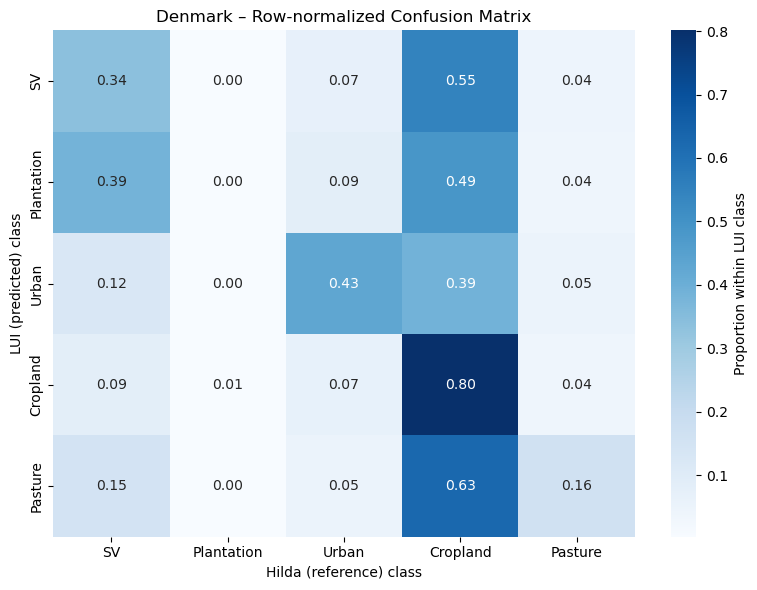

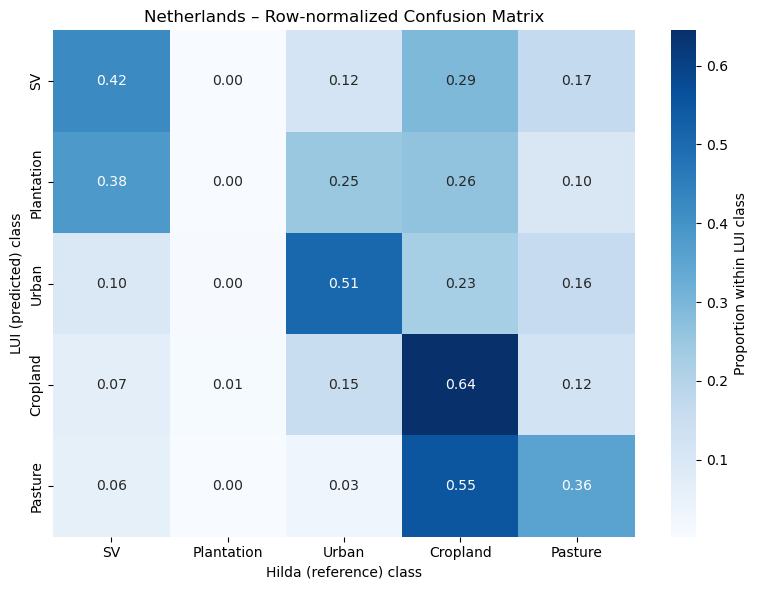

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def normalize_rows(cm):
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm / row_sums
    return cm_norm

def plot_row_norm(cm, labels, title):
    cm_norm = normalize_rows(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Proportion within LUI class'})
    plt.xlabel("Hilda (reference) class")
    plt.ylabel("LUI (predicted) class")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---- Denmark ----
plot_row_norm(cm_d, labels,
              title="Denmark – Row-normalized Confusion Matrix")

# ---- Netherlands ----
plot_row_norm(cm_n, labels,
              title="Netherlands – Row-normalized Confusion Matrix")

# Compare BII

In [4]:
#--- Load BII layers ---
bii_dnk_gess_18 = rxr.open_rasterio(base / "Validation/BII/BII_dnk_gessert_2018.tif").squeeze()
bii_nld_gess_18 = rxr.open_rasterio(base / "Validation/BII/BII_nld_gessert_2018.tif").squeeze()

bii_glob_nguy_18 = rxr.open_rasterio(base / "Validation/BII/BII_global_nguyen_2018_v2.tif").squeeze()

bii_euro_lama = rxr.open_rasterio(base / "Validation/BII/BII_europe_lamasus.tif")
bii_euro_lama_18 = bii_euro_lama.sel(band=21)

bii_dnk_own_18 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/bii_world_dnk_2018_v7_100m.tif").squeeze()
bii_nld_own_18 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/bii_world_nld_2018_v7_100m.tif").squeeze()


# --- Print CRS & shape (super simple) ---
print("DK gess 2018:", bii_dnk_gess_18.rio.crs, bii_dnk_gess_18.shape)
print("NL gess 2018:", bii_nld_gess_18.rio.crs, bii_nld_gess_18.shape)
print("Global Nguyen 2018:", bii_glob_nguy_18.rio.crs, bii_glob_nguy_18.shape)
print("Europe Lamasus:", bii_euro_lama_18.rio.crs, bii_euro_lama_18.shape)
print("DK own 2018:", bii_dnk_own_18.rio.crs, bii_dnk_own_18.shape)
print("NL own 2018:", bii_nld_own_18.rio.crs, bii_nld_own_18.shape)


DK gess 2018: EPSG:4326 (3611, 7923)
NL gess 2018: EPSG:4326 (3170, 4305)
Global Nguyen 2018: EPSG:4326 (7157, 18000)
Europe Lamasus: EPSG:3035 (4525, 5634)
DK own 2018: EPSG:3035 (3536, 4509)
NL own 2018: EPSG:3035 (3131, 2762)


In [4]:
print(bii_euro_lama.attrs)

{'AREA_OR_POINT': 'Area', 'STATISTICS_MAXIMUM': 1, 'STATISTICS_MEAN': -9999, 'STATISTICS_MINIMUM': 0.51617860794067, 'STATISTICS_STDDEV': -9999, '_FillValue': nan, 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': ('Species richness__2000', 'Species richness__2010', 'Species richness__2018', 'Total abundance__2000', 'Total abundance__2010', 'Total abundance__2018', 'Geometric mean abundance__2000', 'Geometric mean abundance__2010', 'Geometric mean abundance__2018', 'Sorensen__2000', 'Sorensen__2010', 'Sorensen__2018', 'Bray-Curtis__2000', 'Bray-Curtis__2010', 'Bray-Curtis__2018', 'Canberra__2000', 'Canberra__2010', 'Canberra__2018', 'BII__2000', 'BII__2010', 'BII__2018')}


In [5]:
#--- Reproject & Clip ---#


def align_to_country(src, country_ref):
    """
    Reproject + align + mask using reference raster exactly.
    - Same CRS
    - Same extent
    - Same resolution
    - Masked using country_ref (NaN outside country)
    """
    # 1. Reproject & match extent/resolution
    aligned = src.rio.reproject_match(country_ref)
    
    # 2. Mask: keep only where reference has data
    aligned = aligned.where(~np.isnan(country_ref))
    
    return aligned

#_______Denmark_______#

ref_dk = bii_dnk_own_18  # 353 × 450, EPSG:3035

bii_gess_18_dk = align_to_country(bii_dnk_gess_18, ref_dk)
bii_nguy_18_dk = align_to_country(bii_glob_nguy_18, ref_dk)
bii_lama_18_dk = align_to_country(bii_euro_lama_18, ref_dk)

#_______Nerherlands_______#

ref_nl = bii_nld_own_18  # 313 × 276, EPSG:3035

bii_gess_18_nl   = align_to_country(bii_nld_gess_18, ref_nl)
bii_nguy_18_nl = align_to_country(bii_glob_nguy_18, ref_nl)
bii_lama_18_nl = align_to_country(bii_euro_lama_18, ref_nl)


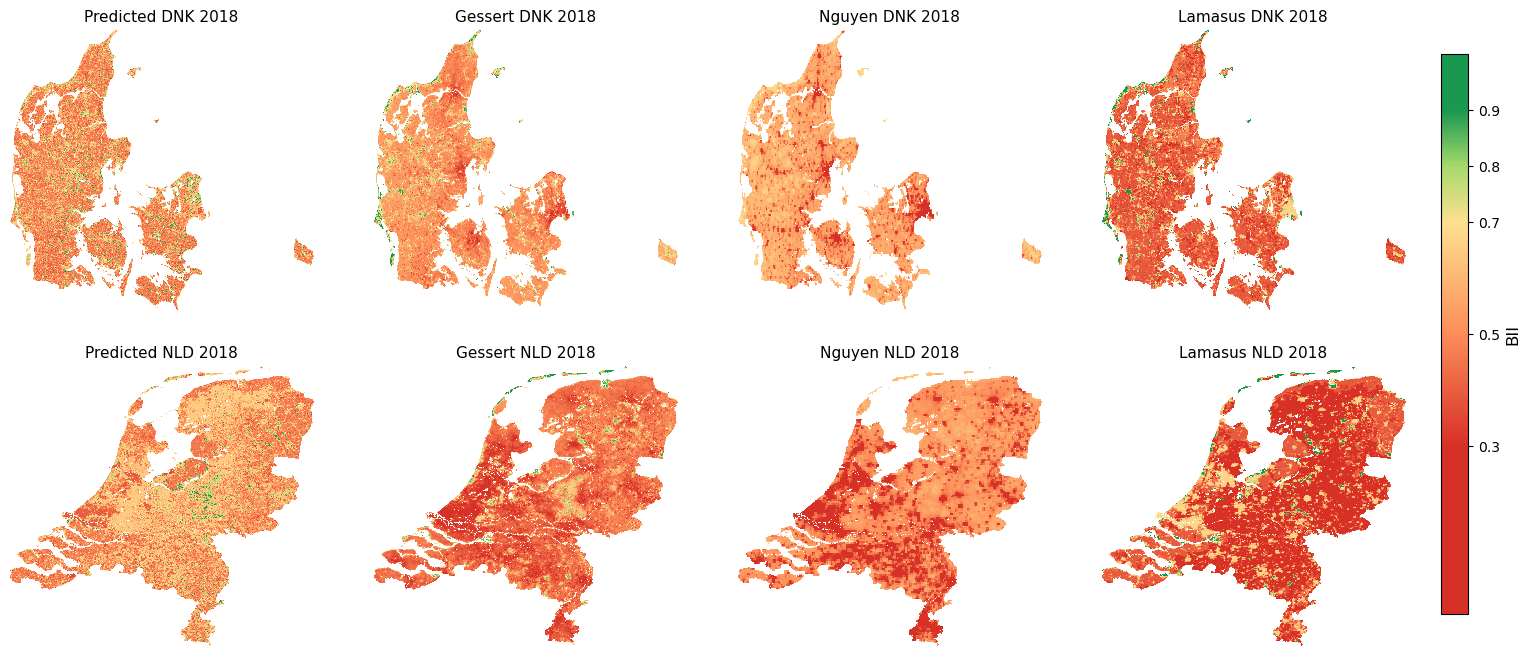

In [24]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Your 8 maps
plots = [
    ("Predicted DNK 2018", bii_dnk_own_18),
    ("Gessert DNK 2018",   bii_gess_18_dk),
    ("Nguyen DNK 2018",    bii_nguy_18_dk),
    ("Lamasus DNK 2018",   bii_lama_18_dk),
    ("Predicted NLD 2018",       bii_nld_own_18),
    ("Gessert NLD 2018",   bii_gess_18_nl),
    ("Nguyen NLD 2018",    bii_nguy_18_nl),
    ("Lamasus NLD 2018",   bii_lama_18_nl),
]

def clean(da):
    da = da.copy()
    for k in ["long_name", "description", "units"]:
        da.attrs.pop(k, None)
    return da

plots = [(title, clean(da)) for title, da in plots]

# --- Colormap: positions ARE the actual data values (vmin=0, vmax=1) ---
# Triple-checked against screenshot:
#   0.3 → deep red
#   0.5 → clear orange      ← was broken before (was red-orange)
#   0.7 → pale yellow
#   0.8 → light green
#   0.9 → medium/dark green
cmap_colors = [
    (0.0,  "#D73027"),   # deep red    — extends below 0.3
    (0.3,  "#D73027"),   # deep red
    (0.5,  "#FC8D59"),   # orange
    (0.7,  "#FEE090"),   # pale yellow
    (0.8,  "#A6D96A"),   # light green
    (0.9,  "#1A9850"),   # medium green
    (1.0,  "#1A9850"),   # medium green — extends above 0.9
]

cmap = mcolors.LinearSegmentedColormap.from_list(
    "qgis_ramp", cmap_colors
)

vmin, vmax = 0.0, 1.0   # keep 0–1 so positions above map directly to colormap

# --- Plot grid ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, (title, da) in zip(axes, plots):
    im = da.plot.imshow(
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False
    )
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

# --- Colorbar with matching ticks ---
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cb = plt.colorbar(im, cax=cax)
cb.set_label("BII", fontsize=12)
cb.set_ticks([0.3, 0.5, 0.7, 0.8, 0.9])

plt.subplots_adjust(right=0.9)
plt.show()

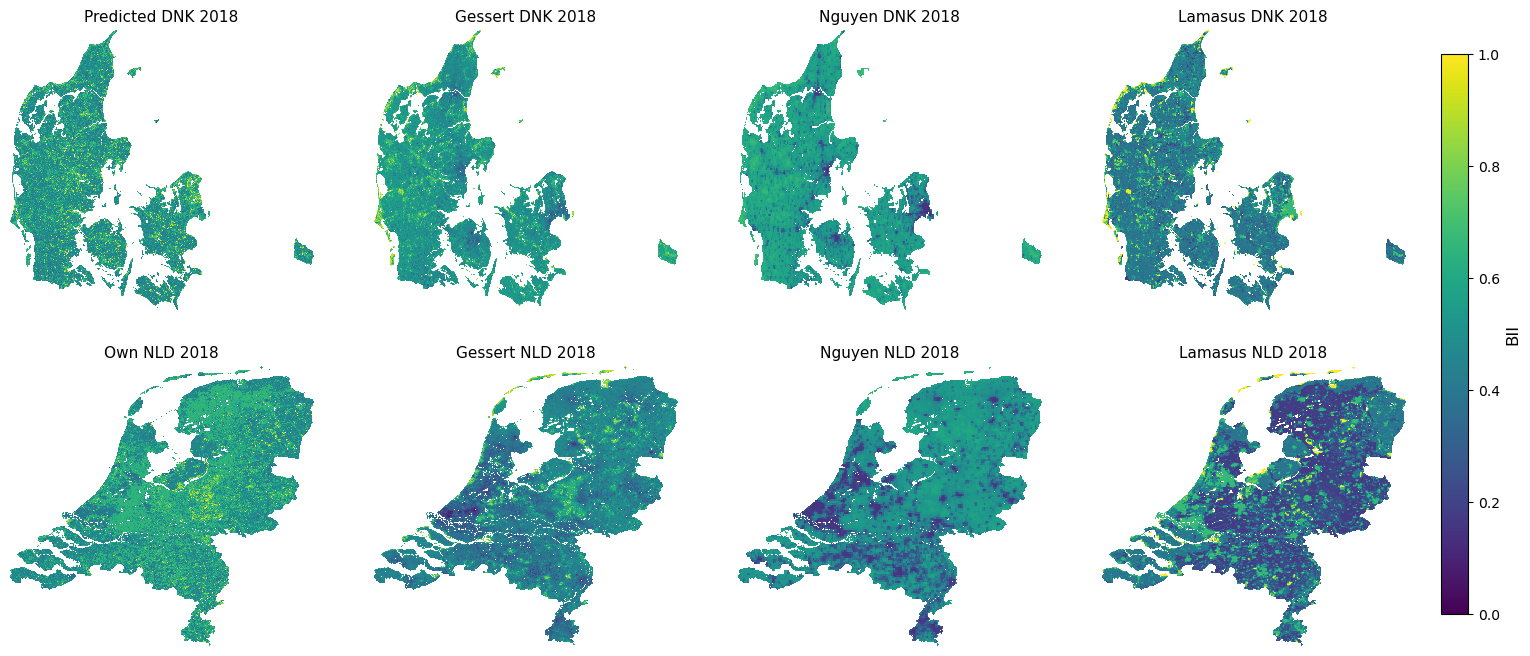

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Your 8 maps
plots = [
    ("Predicted DNK 2018", bii_dnk_own_18),
    ("Gessert DNK 2018", bii_gess_18_dk),
    ("Nguyen DNK 2018", bii_nguy_18_dk),
    ("Lamasus DNK 2018", bii_lama_18_dk),
    ("Own NLD 2018", bii_nld_own_18),
    ("Gessert NLD 2018", bii_gess_18_nl),
    ("Nguyen NLD 2018", bii_nguy_18_nl),
    ("Lamasus NLD 2018", bii_lama_18_nl),
]

# Clean metadata to avoid long labels
def clean(da):
    da = da.copy()
    for k in ["long_name", "description", "units"]:
        da.attrs.pop(k, None)
    return da

plots = [(title, clean(da)) for title, da in plots]

# Create grid (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

# Common settings
vmin, vmax = 0, 1
cmap = "viridis"

# Plot the rasters
for ax, (title, da) in zip(axes, plots):
    im = da.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

# --- Add colorbar in its own axis ---
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]

cb = plt.colorbar(im, cax=cax)
cb.set_label("BII", fontsize=12)

plt.subplots_adjust(right=0.9)  # make room for the colorbar
plt.show()

### Stats

In [25]:
import numpy as np
import pandas as pd

def compare_maps(ref, other):
    """
    Returns RMSE, MAE, and Pearson correlation between two aligned rasters.
    Ignores NaNs automatically.
    """
    a = ref.values.flatten()
    b = other.values.flatten()

    mask = ~np.isnan(a) & ~np.isnan(b)

    a = a[mask]
    b = b[mask]

    rmse = np.sqrt(np.mean((a - b)**2))
    mae  = np.mean(np.abs(a - b))
    corr = np.corrcoef(a, b)[0, 1]

    return pd.Series({"RMSE": rmse, "MAE": mae, "r": corr})


In [26]:
print("DK — Gessert:", compare_maps(bii_dnk_own_18, bii_gess_18_dk))
print("DK — Nguyen:", compare_maps(bii_dnk_own_18, bii_nguy_18_dk))
print("DK — Lamasus:", compare_maps(bii_dnk_own_18, bii_lama_18_dk))

print("NL — Gessert:", compare_maps(bii_nld_own_18, bii_gess_18_nl))
print("NL — Nguyen:", compare_maps(bii_nld_own_18, bii_nguy_18_nl))
print("NL — Lamasus:", compare_maps(bii_nld_own_18, bii_lama_18_nl))

DK — Gessert: RMSE    0.136818
MAE     0.101900
r       0.212109
dtype: float64
DK — Nguyen: RMSE    0.153407
MAE     0.121191
r      -0.046344
dtype: float64
DK — Lamasus: RMSE    0.192190
MAE     0.142083
r       0.167992
dtype: float64
NL — Gessert: RMSE    0.179990
MAE     0.143802
r       0.174040
dtype: float64
NL — Nguyen: RMSE    0.195130
MAE     0.150748
r       0.008175
dtype: float64
NL — Lamasus: RMSE    0.289571
MAE     0.243381
r      -0.007524
dtype: float64


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.stats import gaussian_kde
# from matplotlib.colors import Normalize

# def density_compare_trio(predicted, references, ref_labels):
#     fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

#     plot_data = []
#     for ref in references:
#         a = ref.values.flatten()
#         b = predicted.values.flatten()
#         mask = ~np.isnan(a) & ~np.isnan(b)
#         x, y = a[mask], b[mask]
#         xy = np.vstack([x, y])
#         density = gaussian_kde(xy)(xy)
#         plot_data.append((x, y, density))

#     all_dens = np.concatenate([d[2] for d in plot_data])
#     norm = Normalize(vmin=all_dens.min(), vmax=all_dens.max())

#     for ax, (x, y, density), label in zip(axes, plot_data, ref_labels):
#         idx = density.argsort()
#         x, y, density = x[idx], y[idx], density[idx]

#         sc = ax.scatter(x, y, c=density, s=1, cmap="inferno", norm=norm)
#         ax.plot([0, 1], [0, 1], "r--", lw=1)
#         ax.set_xlabel(f"Reference BII ({label})")
#         ax.set_ylabel("Predicted BII")
#         ax.set_title(f"vs {label}")
#         ax.set_xlim(0, 1)
#         ax.set_ylim(0, 1)
#         ax.set_aspect("equal")

#     # # Manual colorbar axis at the bottom
#     # cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.03])  # [left, bottom, width, height]
#     # fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", label="Density")

#     # fig.suptitle("Predicted BII vs Reference Maps", fontsize=14)
#     # fig.subplots_adjust(bottom=0.15, top=0.9, wspace=0.35)
#     # plt.show()

#     # colorbar on the right
#     cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
#     fig.colorbar(sc, cax=cbar_ax, orientation="vertical", label="Density")

#     fig.suptitle("Predicted BII vs Reference Maps", fontsize=14)
#     fig.subplots_adjust(right=0.9, top=0.9, wspace=0.35)
#     plt.show()

# density_compare_trio(
#     bii_dnk_own_18,
#     [bii_gess_18_dk, bii_nguy_18_dk, bii_lama_18_dk],
#     ["Gessert", "Nguyen", "Lamasus"]
# )

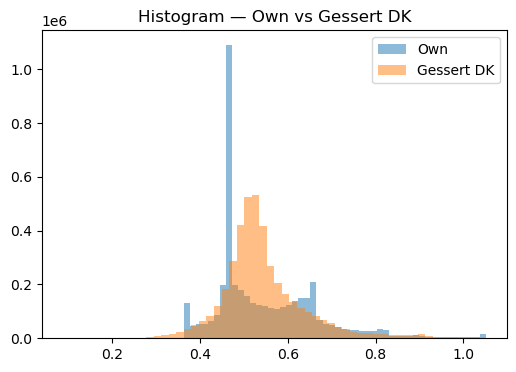

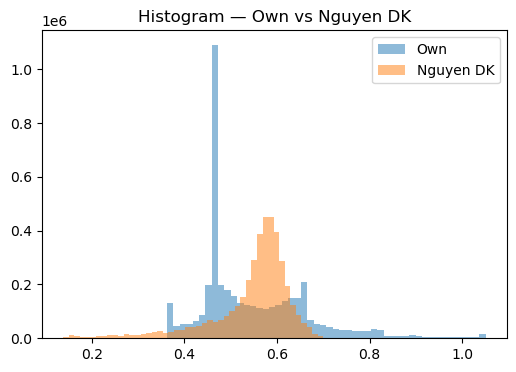

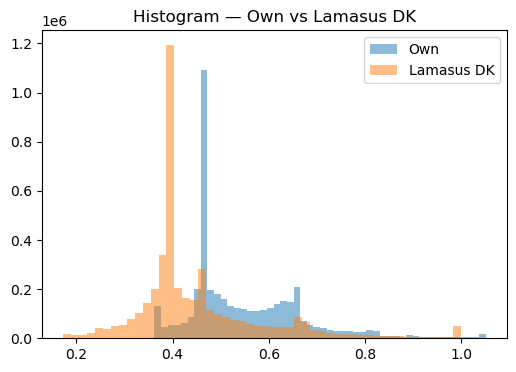

In [8]:
def hist_compare(ref, other, title):
    plt.figure(figsize=(6,4))
    plt.hist(ref.values.flatten(), bins=50, alpha=0.5, label="Own")
    plt.hist(other.values.flatten(), bins=50, alpha=0.5, label=title)
    plt.legend()
    plt.title(f"Histogram — Own vs {title}")
    plt.show()

    
hist_compare(bii_dnk_own_18, bii_gess_18_dk, "Gessert DK")
hist_compare(bii_dnk_own_18, bii_nguy_18_dk, "Nguyen DK")
hist_compare(bii_dnk_own_18, bii_lama_18_dk, "Lamasus DK")


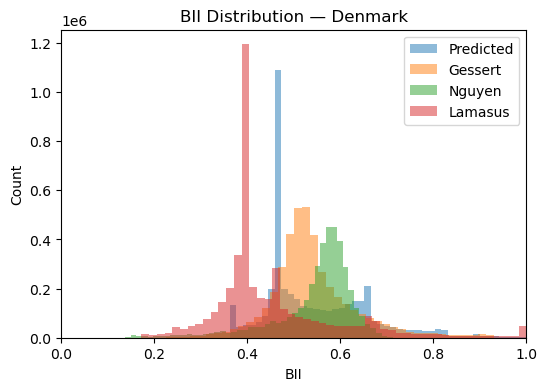

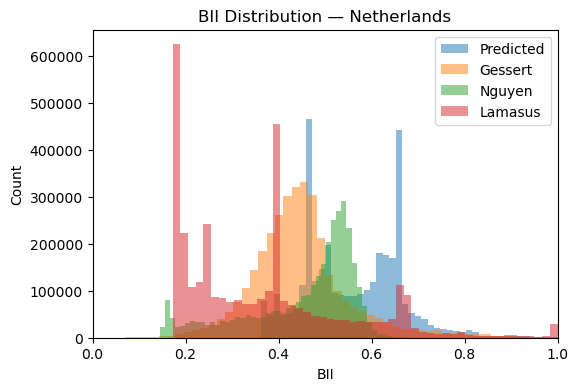

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def hist_all(country, own, gess, nguy, lama):
    """
    One histogram overlay for all BII layers of a country.
    """

    # flatten + drop NaNs
    def clean(x):
        arr = x.values.flatten()
        return arr[~np.isnan(arr)]

    own_v = clean(own)
    gess_v = clean(gess)
    nguy_v = clean(nguy)
    lama_v = clean(lama)

    plt.figure(figsize=(6, 4))
    plt.hist(own_v, bins=50, alpha=0.5, label="Predicted", density=False)
    plt.hist(gess_v, bins=50, alpha=0.5, label="Gessert", density=False)
    plt.hist(nguy_v, bins=50, alpha=0.5, label="Nguyen", density=False)
    plt.hist(lama_v, bins=50, alpha=0.5, label="Lamasus", density=False)

    plt.title(f"BII Distribution — {country}")
    plt.xlabel("BII")
    plt.ylabel("Count")
    plt.legend()
    plt.xlim(0, 1)
    plt.show()


# 🇩🇰 Denmark
hist_all(
    "Denmark",
    bii_dnk_own_18,
    bii_gess_18_dk,
    bii_nguy_18_dk,
    bii_lama_18_dk
)

# 🇳🇱 Netherlands
hist_all(
    "Netherlands",
    bii_nld_own_18,
    bii_gess_18_nl,
    bii_nguy_18_nl,
    bii_lama_18_nl
)

In [7]:
# Denmark differences
diff_gess_dk   = bii_gess_18_dk  - bii_dnk_own_18
diff_nguy_dk   = bii_nguy_18_dk  - bii_dnk_own_18
diff_lama_dk   = bii_lama_18_dk  - bii_dnk_own_18

# Netherlands differences
diff_gess_nl   = bii_gess_18_nl  - bii_nld_own_18
diff_nguy_nl   = bii_nguy_18_nl  - bii_nld_own_18
diff_lama_nl   = bii_lama_18_nl  - bii_nld_own_18

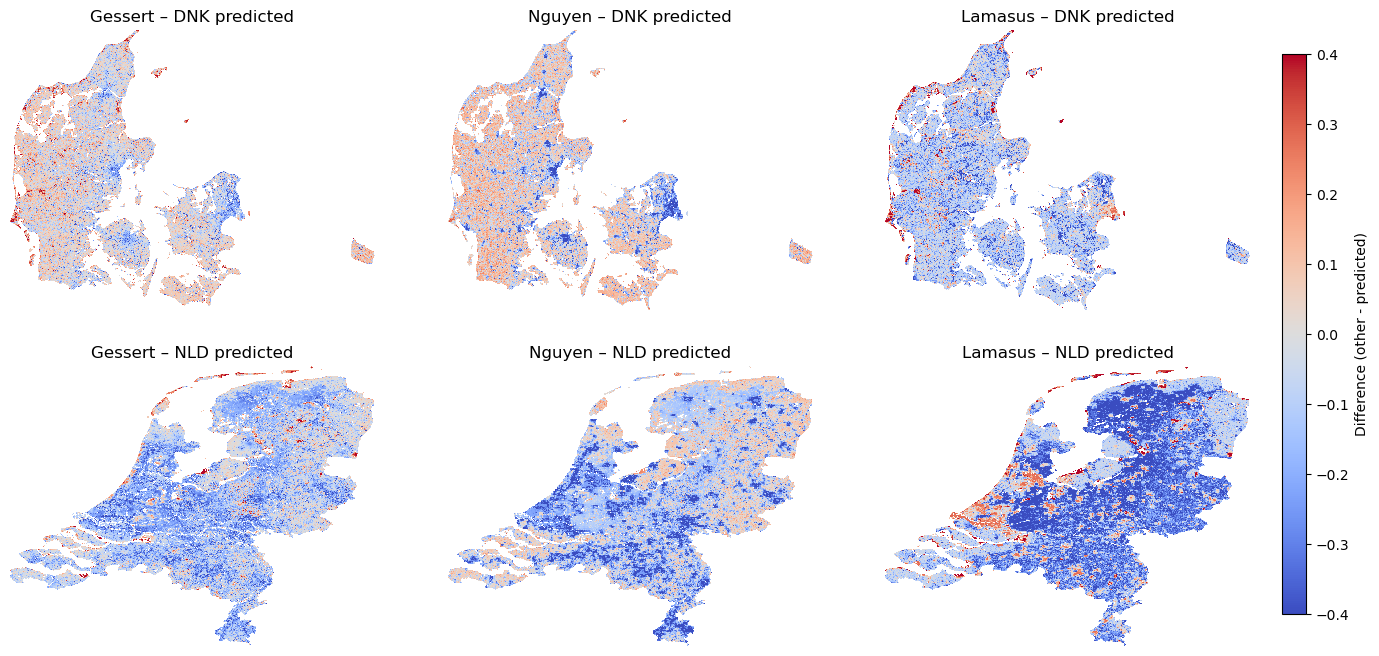

In [8]:
import matplotlib.pyplot as plt

plots = [
    ("Gessert – DNK predicted",   diff_gess_dk),
    ("Nguyen – DNK predicted", diff_nguy_dk),
    ("Lamasus – DNK predicted", diff_lama_dk),
    ("Gessert – NLD predicted",   diff_gess_nl),
    ("Nguyen – NLD predicted", diff_nguy_nl),
    ("Lamasus – NLD predicted", diff_lama_nl),
]

# Divergent colormap: negative = blue, positive = red
cmap = "coolwarm"
vmax = 0.4   # symmetric range, adjust if needed
vmin = -vmax

# Create grid: 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, (title, da) in zip(axes, plots):
    im = da.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(title)
    ax.set_axis_off()

# Dedicated colorbar axis on right
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cb = plt.colorbar(im, cax=cax)
cb.set_label("Difference (other - predicted)")

plt.subplots_adjust(right=0.9)
plt.show()

# Compare Bioscore Denmark

### Download bioscore
#### ── Direct download URL ──────────────────────────────────────────
URL = https://files-miljoegis.mim.dk/biodiversitet/biodiversitet_2021.zip
Source: https://arealdata.miljoeportal.dk/datasets/urn:dmp:ds:biodiversitetskortet-datapakke


## Data prep

In [9]:
proxy = rxr.open_rasterio(base / "Validation/Bioscore/Proxzysum_tiff.tif").squeeze()
bioscore = rxr.open_rasterio(base / "Validation/Bioscore/Bioscore_tiff.tif").squeeze()
artscore = rxr.open_rasterio(base / "Validation/Bioscore/Artscore_tiff.tif").squeeze()

bii_dnk_pred_21 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/bii_world_dnk_2021_v7_100m.tif").squeeze()
ab_dnk_pred_21 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/ab_world_dnk_2021_v7_100m.tif").squeeze()
cd_dnk_pred_21 = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/cd_world_dnk_2021_v7_100m.tif").squeeze()


In [10]:
from rasterio.enums import Resampling

# your predicted layers are already in EPSG:3035 at ~1km — use as target grid
target = bii_dnk_pred_21

# reproject + resample reference layers to match predicted grid (mean of pixels within each 1km cell)
proxy_1km = proxy.rio.reproject_match(target, resampling=Resampling.average)
bioscore_1km = bioscore.rio.reproject_match(target, resampling=Resampling.average)
artscore_1km = artscore.rio.reproject_match(target, resampling=Resampling.average)

# mask nodata
proxy_1km = proxy_1km.where(proxy_1km != proxy_1km.rio.nodata)
bioscore_1km = bioscore_1km.where(bioscore_1km != bioscore_1km.rio.nodata)
artscore_1km = artscore_1km.where(artscore_1km != artscore_1km.rio.nodata)

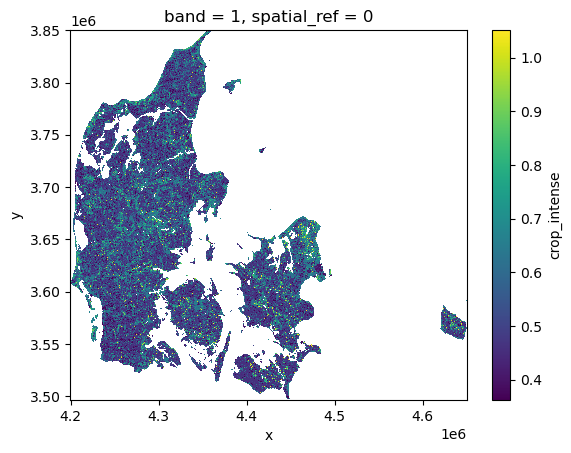

In [11]:
target.plot()

NameError: name 'pred' is not defined

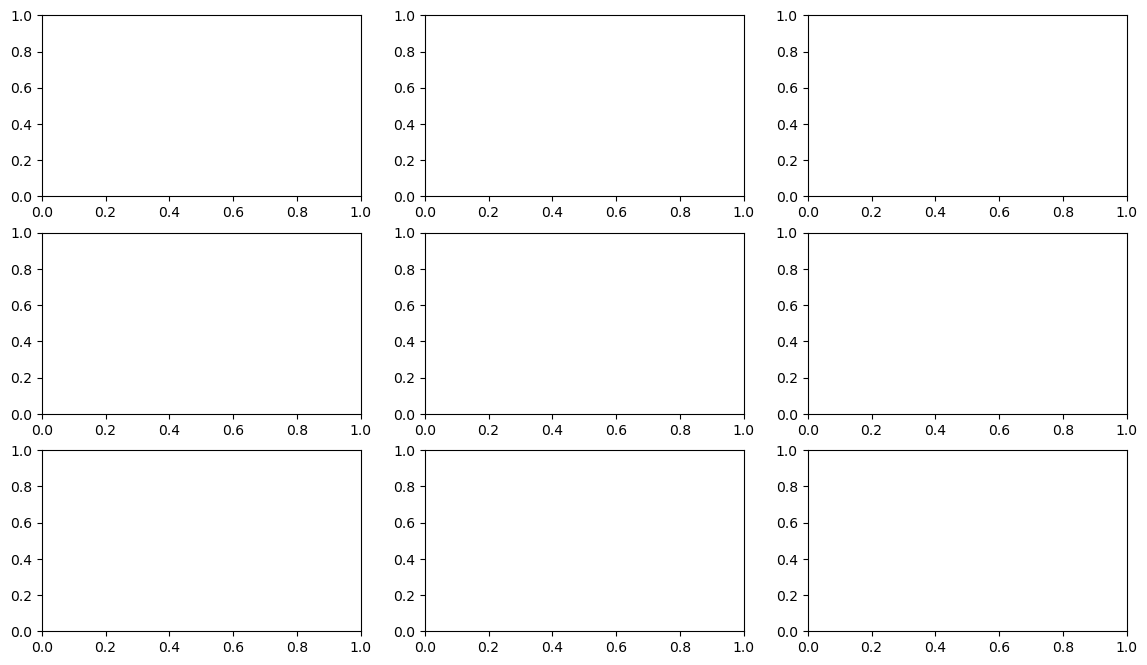

In [12]:
# # plot predicted vs reference for each pair, with hexbin density and correlation coefficient in title

fig, axes = plt.subplots(3, 3, figsize=(14, 8))

for i, (pname, pdata) in enumerate(pred.items()):
    for j, (rname, rdata) in enumerate(ref.items()):
        ax = axes[i, j]
        mask = np.isfinite(pdata.values) & np.isfinite(rdata.values)
        x, y = rdata.values[mask], pdata.values[mask]
        ax.hexbin(x, y, gridsize=50, cmap="viridis", mincnt=1)
        # binned trend + uncertainty
        bins = np.linspace(x.min(), x.max(), 50)
        idx = np.digitize(x, bins)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        counts = np.array([np.sum(idx == k) for k in range(1, len(bins))])
        bin_means = np.array([y[idx == k].mean() if counts[k-1] > 0 else np.nan for k in range(1, len(bins))])
        bin_std = np.array([y[idx == k].std() if counts[k-1] > 1 else np.nan for k in range(1, len(bins))])
        bin_se = bin_std / np.sqrt(counts)
        valid = np.isfinite(bin_means) & np.isfinite(bin_se)
        mu = uniform_filter1d(bin_means[valid], size=5)
        se = uniform_filter1d(bin_se[valid], size=5)
        xv = bin_centers[valid]
        ax.plot(xv, mu, "r-", lw=2.5)
        ax.fill_between(xv, mu - 1.96*se, mu + 1.96*se, color="red", alpha=0.2)
        r = np.corrcoef(x, y)[0, 1]
        ax.set_xlabel(rname)
        ax.set_ylabel(pname)
        ax.set_title(f"r = {r:.3f}")

plt.tight_layout()
plt.show()

/home/georg/python/miniconda3/envs/bii/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


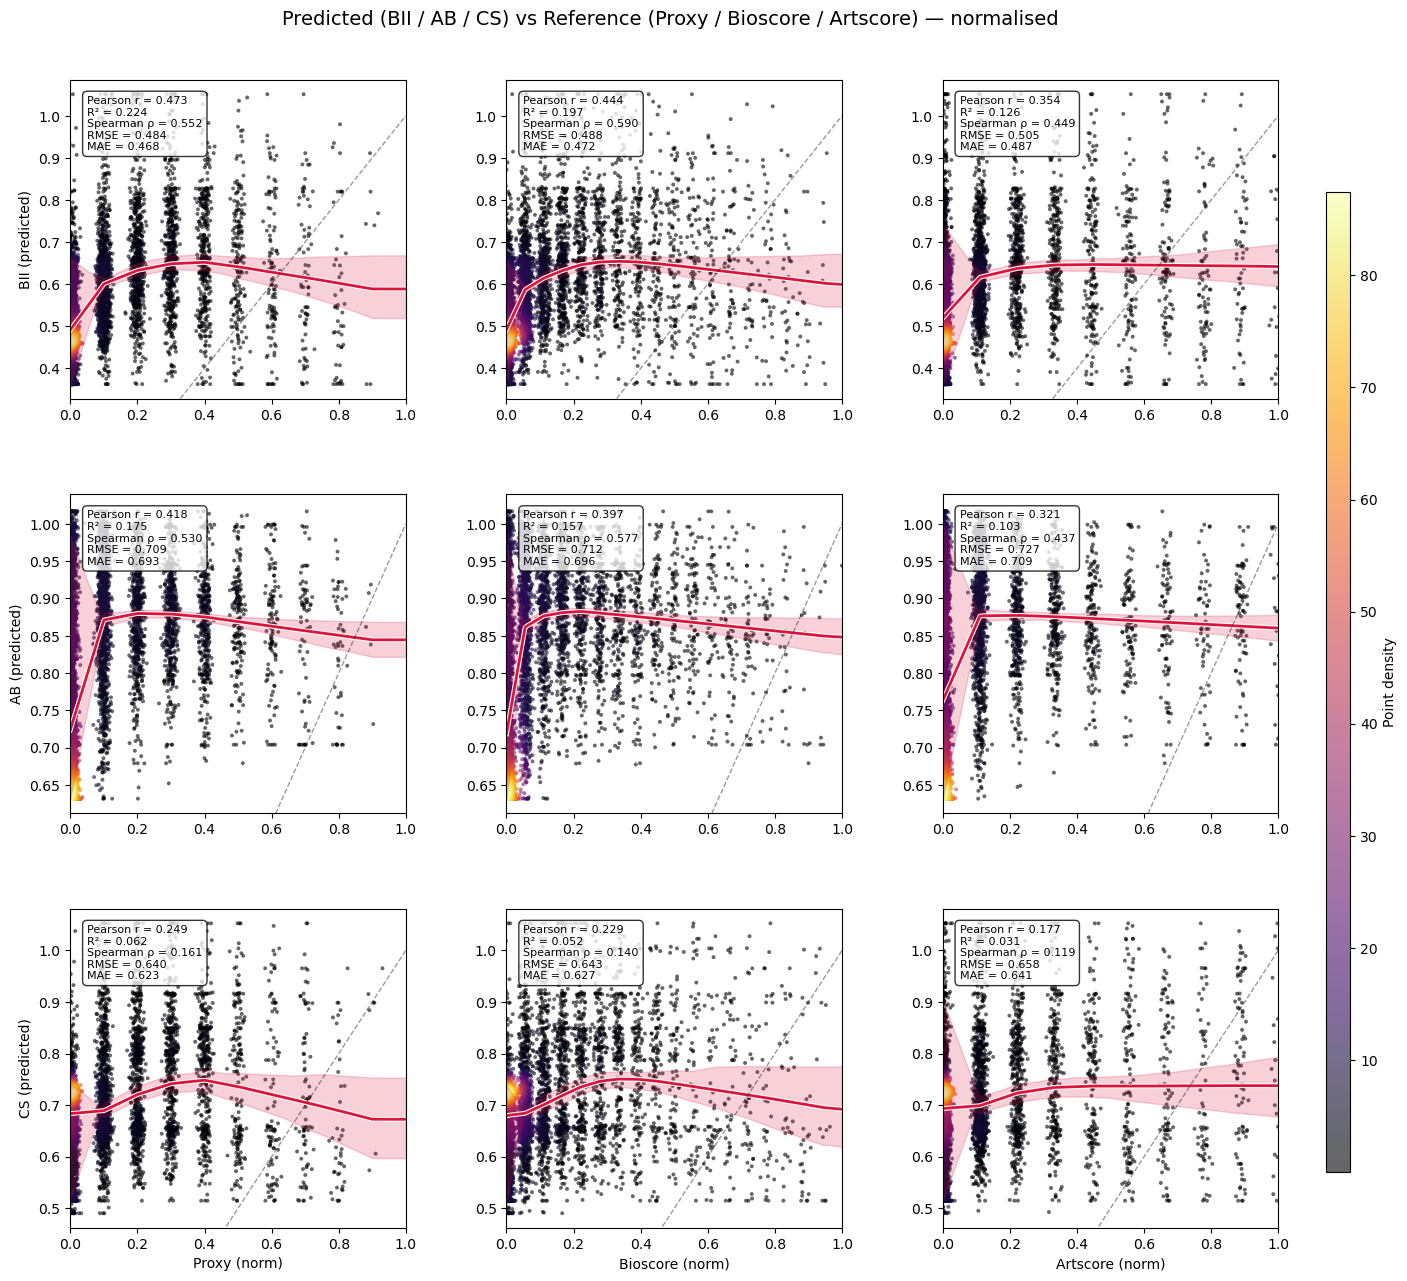

In [13]:
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import spearmanr, gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

def normalize_01(da):
    vmin, vmax = float(da.min()), float(da.max())
    return (da - vmin) / (vmax - vmin)

proxy_norm    = normalize_01(proxy_1km)
bioscore_norm = normalize_01(bioscore_1km)
artscore_norm = normalize_01(artscore_1km)

pred = {
    "BII (predicted)": bii_dnk_pred_21,
    "AB (predicted)":  ab_dnk_pred_21,
    "CS (predicted)":  cd_dnk_pred_21,
}

ref = {
    "Proxy (norm)":    proxy_norm,
    "Bioscore (norm)": bioscore_norm,
    "Artscore (norm)": artscore_norm,
}

def bootstrap_lowess(x, y, n_boot=200, frac=0.3, num_points=200, max_pts=5000):
    x_grid = np.linspace(x.min(), x.max(), num_points)
    boot_curves = np.zeros((n_boot, num_points))
    for b in range(n_boot):
        if len(x) > max_pts:
            idx = np.random.choice(len(x), size=max_pts, replace=False)
        else:
            idx = np.random.choice(len(x), size=len(x), replace=True)
        xb, yb = x[idx], y[idx]
        smooth = lowess(yb, xb, frac=frac, return_sorted=True)
        boot_curves[b] = np.interp(x_grid, smooth[:, 0], smooth[:, 1])
    mean_curve = np.mean(boot_curves, axis=0)
    ci_lo = np.percentile(boot_curves, 2.5, axis=0)
    ci_hi = np.percentile(boot_curves, 97.5, axis=0)
    return x_grid, mean_curve, ci_lo, ci_hi

def annotate_stats(ax, x, y):
    r_p = np.corrcoef(x, y)[0, 1]
    r2  = r_p ** 2
    rmse = np.sqrt(np.mean((x - y)**2))
    mae  = np.mean(np.abs(x - y))
    rho, _ = spearmanr(x, y)
    text = (f"Pearson r = {r_p:.3f}\n"
            f"R² = {r2:.3f}\n"
            f"Spearman ρ = {rho:.3f}\n"
            f"RMSE = {rmse:.3f}\n"
            f"MAE = {mae:.3f}")
    ax.text(0.05, 0.95, text, transform=ax.transAxes,
            fontsize=8, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

# ONE figure creation only
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for i, (pname, pdata) in enumerate(pred.items()):
    for j, (rname, rdata) in enumerate(ref.items()):
        ax = axes[i, j]
        mask = np.isfinite(pdata.values) & np.isfinite(rdata.values)
        x = rdata.values[mask]
        y = pdata.values[mask]

        max_kde = 10000
        if len(x) > max_kde:
            sub = np.random.choice(len(x), size=max_kde, replace=False)
            xs, ys = x[sub], y[sub]
        else:
            xs, ys = x, y

        jitter = (x.max() - x.min()) * 0.01
        xj = xs + np.random.normal(0, jitter, len(xs))

        xy = np.vstack([xj, ys])
        density = gaussian_kde(xy)(xy)
        idx = density.argsort()
        xj, ys_sorted, density = xj[idx], ys[idx], density[idx]

        sc = ax.scatter(xj, ys_sorted, c=density, s=8, cmap="inferno",
                        alpha=0.6, edgecolors="none")

        xg, mu, ci_lo, ci_hi = bootstrap_lowess(x, y, n_boot=200, frac=0.3)
        ax.plot(xg, mu, color="white", lw=3.5)
        ax.plot(xg, mu, color="crimson", lw=2)
        ax.fill_between(xg, ci_lo, ci_hi, color="crimson", alpha=0.2)

        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)

        annotate_stats(ax, x, y)

        ypad = (y.max() - y.min()) * 0.05
        ax.set_ylim(y.min() - ypad, y.max() + ypad)
        ax.set_xlim(0, 1)

        if i == 2:
            ax.set_xlabel(rname)
        else:
            ax.set_xlabel("")
        if j == 0:
            ax.set_ylabel(pname)
        else:
            ax.set_ylabel("")

fig.subplots_adjust(right=0.88, top=0.93, wspace=0.3, hspace=0.3)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(sc, cax=cbar_ax, label="Point density")
fig.suptitle("Predicted (BII / AB / CS) vs Reference (Proxy / Bioscore / Artscore) — normalised",
             fontsize=14)
plt.show()

In [25]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# top row: reference layers
for ax, (name, data) in zip(axes[0], ref.items()):
    data.plot(ax=ax, cmap="YlGn", add_colorbar=True)
    ax.set_title(name)
    ax.set_aspect("equal")

# bottom row: predicted layers + empty
bii_dnk_pred_21.plot(ax=axes[1, 0], cmap="YlGn", add_colorbar=True)
axes[1, 0].set_title("BII predicted")
axes[1, 0].set_aspect("equal")

ab_dnk_pred_21.plot(ax=axes[1, 1], cmap="YlGn", add_colorbar=True)
axes[1, 1].set_title("Abundance predicted")
axes[1, 1].set_aspect("equal")

cd_dnk_pred_21.plot(ax=axes[1, 2], cmap="YlGn", add_colorbar=True)
axes[1, 2].set_title("Compositional similarity predicted")
axes[1, 2].set_aspect("equal")

axes[1, 3].axis("off")

plt.tight_layout()
plt.show()

IndexError: index 3 is out of bounds for axis 1 with size 3

: 

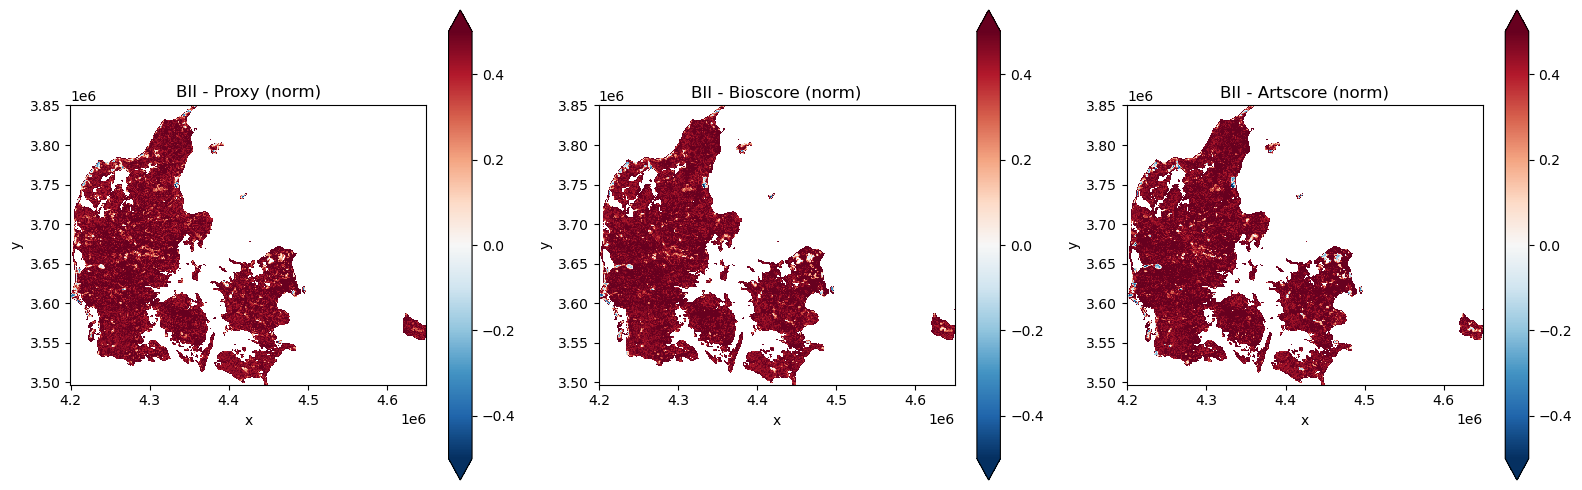

In [25]:
# normalize reference layers to 0-1 for fair comparison
def norm01(da):
    mn, mx = float(da.min()), float(da.max())
    return (da - mn) / (mx - mn)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, data) in zip(axes, ref.items()):
    diff = bii_dnk_pred_21 - norm01(data)
    diff.plot(ax=ax, cmap="RdBu_r", vmin=-0.5, vmax=0.5, add_colorbar=True)
    ax.set_title(f"BII - {name} (norm)")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Gridcell network No of species

### Data prep

In [15]:
import pandas as pd

# --- edit these ---
txt_path = base / "Validation/gridcell_Petersen-2024.txt"   # tab-delimited source
csv_path = base / "Validation/gridcell_v2.csv"  # target CSV
# ------------------

df = pd.read_csv(txt_path, sep="\t", dtype=str, keep_default_na=False)
df.to_csv(csv_path, index=False)
print(f"CSV written to: {csv_path}")

CSV written to: /home/georg/data/LEON_P5_BII/Validation/gridcell_v2.csv


In [16]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import fiona

# ==== EDIT THIS BASE FOLDER TO MATCH YOUR MACHINE ====


gpkg_path = base / "Validation" / "gridcell_dnk.gpkg"
csv_path  = base / "Validation" / "gridcell_v2.csv"
out_gpkg  = base / "Validation" / "gridcell_dnk_v2.gpkg"

key = "WORLDMAP_C"                     # same on both sides per your snippet
csv_cols_to_add = ["Richness", "Rare-quartile"]

# ---- sanity checks ----
assert gpkg_path.exists(), f"GPKG not found: {gpkg_path}"
assert csv_path.exists(),  f"CSV not found:  {csv_path}"

# ---- get layer name from GPKG ----
layers = fiona.listlayers(str(gpkg_path))
if not layers:
    raise RuntimeError(f"No layers found in {gpkg_path}")
layer_name = layers[0]          # choose the first, or set explicitly if you know it
print("Using layer:", layer_name)
out_layer = f"{layer_name}_joined"

# ---- read GeoPackage ----
gdf = gpd.read_file(gpkg_path, layer=layer_name)

# ---- read CSV, select only needed columns ----
df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)

# ensure required columns exist
required = [key] + csv_cols_to_add
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"CSV missing expected columns: {missing}\nAvailable: {list(df.columns)}")

# keep subset and clean key
df = df[required].copy()
df[key] = df[key].astype(str).str.strip()

# handle duplicates on key (keep first, but warn)
dup_mask = df.duplicated(subset=[key], keep="first")
dup_count = int(dup_mask.sum())
if dup_count:
    print(f"Warning: {dup_count} duplicate row(s) in CSV for key '{key}' — keeping first occurrence.")
    df = df.drop_duplicates(subset=[key], keep="first")

# clean GPKG key
if key not in gdf.columns:
    raise KeyError(f"GPKG layer is missing join key '{key}'. Available: {list(gdf.columns)}")
gdf[key] = gdf[key].astype(str).str.strip()

# ---- merge (left join) ----
joined = gdf.merge(df, on=key, how="left")

# ---- write to new GPKG ----
# Ensure parent directory exists
out_gpkg.parent.mkdir(parents=True, exist_ok=True)

# If you want to overwrite the layer if it exists:
if out_gpkg.exists():
    # geopandas will append a new layer if name differs; to overwrite file, you can unlink:
    # out_gpkg.unlink()  # uncomment if you want a clean file
    pass

joined.to_file(out_gpkg, layer=out_layer, driver="GPKG")
print(f"Wrote joined layer: {out_gpkg}:{out_layer}")

# Optional: quick check of the new columns
print("\nSample of joined columns:")
print(joined[[key] + csv_cols_to_add].head())

Using layer: bii__wmnet_10kmnet_etrs89_exportfeatures
Wrote joined layer: /home/georg/data/LEON_P5_BII/Validation/gridcell_dnk_v2.gpkg:bii__wmnet_10kmnet_etrs89_exportfeatures_joined

Sample of joined columns:
  WORLDMAP_C Richness Rare-quartile
0          1      668            19
1          2      814            31
2          3      717            18
3          7     1064            35
4          6      935            23


### Compare

In [43]:
import geopandas as gpd
import rioxarray as rxr
from pathlib import Path

# Vector grid (has 'No_of_species')
gridcell_dnk = gpd.read_file(base / "Validation/gridcell_dnk_v2.gpkg")
gridcell_dnk = gridcell_dnk.rename(columns={
    "No_of_species": "Richness_v1",
    "Richness": "Richness_v2"
})

# Rasters (rioxarray)
bii_da = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/bii_world_dnk_2021_v7_100m.tif").squeeze()
ab_da  = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/ab_world_dnk_2021_v7_100m.tif").squeeze()
cd_da  = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/cd_world_dnk_2021_v7_100m.tif").squeeze()

lui_18  = rxr.open_rasterio(base / "BII_LU_layer/Land_use_map/v7/lu_intensity_dnk_2018_v7.tif").squeeze()
lui_23  = rxr.open_rasterio(base / "BII_LU_layer/Land_use_map/v7/lu_intensity_dnk_2023_v7.tif").squeeze()


# Make sure rasters share the same CRS
assert bii_da.rio.crs == ab_da.rio.crs, "BII and AB rasters have different CRS!"
assert bii_da.rio.crs == cd_da.rio.crs, "BII and CD rasters have different CRS!"

# Reproject grid to the raster CRS (if needed)
if gridcell_dnk.crs != bii_da.rio.crs:
    gridcell_dnk = gridcell_dnk.to_crs(bii_da.rio.crs)

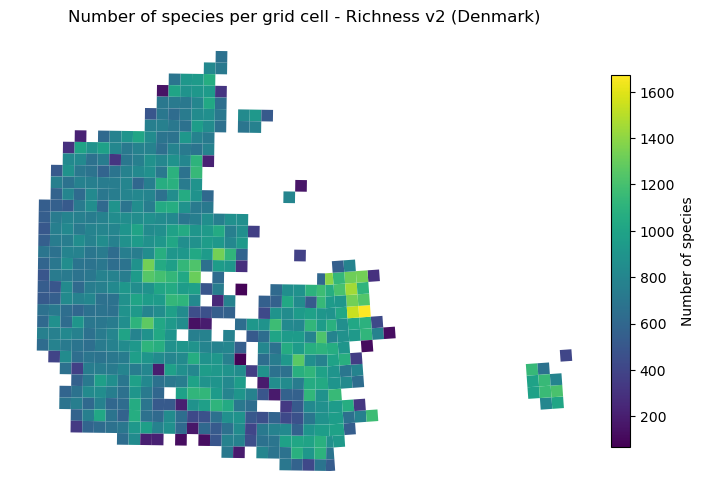

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Convert richness column to numeric ---
gridcell_dnk["Richness_v2"] = pd.to_numeric(
    gridcell_dnk["Richness_v2"],
    errors="coerce"
)

# Drop rows with missing values (recommended)
gridcell_dnk = gridcell_dnk.dropna(subset=["Richness_v2"])

# --- Plot with continuous colorbar ---
fig, ax = plt.subplots(figsize=(8, 10))

vmin = gridcell_dnk["Richness_v2"].min()
vmax = gridcell_dnk["Richness_v2"].max()

gridcell_dnk.plot(
    column="Richness_v2",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    legend=False,
    ax=ax
)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
sm._A = []

cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Number of species")

ax.set_title("Number of species per grid cell - Richness v2 (Denmark)")
ax.set_axis_off()

plt.show()

In [20]:
from rasterstats import zonal_stats
import numpy as np
import pandas as pd

# Using file paths is fastest for rasterstats
bii_path = base / "BII_LU_layer/BII layers/v7/bii_world_dnk_2021_v7_100m.tif"
ab_path  = base / "BII_LU_layer/BII layers/v7/ab_world_dnk_2021_v7_100m.tif"
cd_path  = base / "BII_LU_layer/BII layers/v7/cd_world_dnk_2021_v7_100m.tif"

# Nodata values
bii_nodata = bii_da.rio.nodata
ab_nodata  = ab_da.rio.nodata
cd_nodata  = cd_da.rio.nodata

# Choose whether to include pixels that just touch polygon boundaries
ALL_TOUCHED = False  # set True if your grid cells are small/coarse and you want to include edge pixels

# Compute stats per polygon
stats_list = ["count", "mean", "median", "std", "min", "max"]

zs_bii = zonal_stats(
    gridcell_dnk, bii_path,
    stats=stats_list,
    nodata=bii_nodata,
    all_touched=ALL_TOUCHED,
    geojson_out=False
)

zs_ab = zonal_stats(
    gridcell_dnk, ab_path,
    stats=stats_list,
    nodata=ab_nodata,
    all_touched=ALL_TOUCHED,
    geojson_out=False
)

zs_cd = zonal_stats(
    gridcell_dnk, cd_path,
    stats=stats_list,
    nodata=cd_nodata,
    all_touched=ALL_TOUCHED,
    geojson_out=False
)

# Attach to GeoDataFrame
gridcell_dnk = gridcell_dnk.assign(
    bii_mean   =[d["mean"]   for d in zs_bii],
    bii_median =[d["median"] for d in zs_bii],
    bii_std    =[d["std"]    for d in zs_bii],
    ab_mean    =[d["mean"]   for d in zs_ab],
    ab_median  =[d["median"] for d in zs_ab],
    ab_std     =[d["std"]    for d in zs_ab],
    cd_mean    =[d["mean"]   for d in zs_cd],
    cd_median  =[d["median"] for d in zs_cd],
    cd_std     =[d["std"]    for d in zs_cd],
)

In [44]:
# How many valid cells?
valid = gridcell_dnk[["Richness_v1", "Richness_v2", "Rare-quartile" , "bii_mean", "ab_mean", "cd_mean"]].dropna()
print(f"Valid rows: {len(valid)} / {len(gridcell_dnk)}")

# Check the value ranges
print(valid[["bii_mean", "ab_mean", "cd_mean"]].describe())

Valid rows: 616 / 633
         bii_mean     ab_mean     cd_mean
count  616.000000  616.000000  616.000000
mean     0.545267    0.781773    0.696787
std      0.039074    0.048826    0.025137
min      0.475556    0.675019    0.597153
25%      0.515848    0.747450    0.685229
50%      0.539030    0.771913    0.696854
75%      0.565660    0.806261    0.709976
max      0.704892    0.962402    0.792800


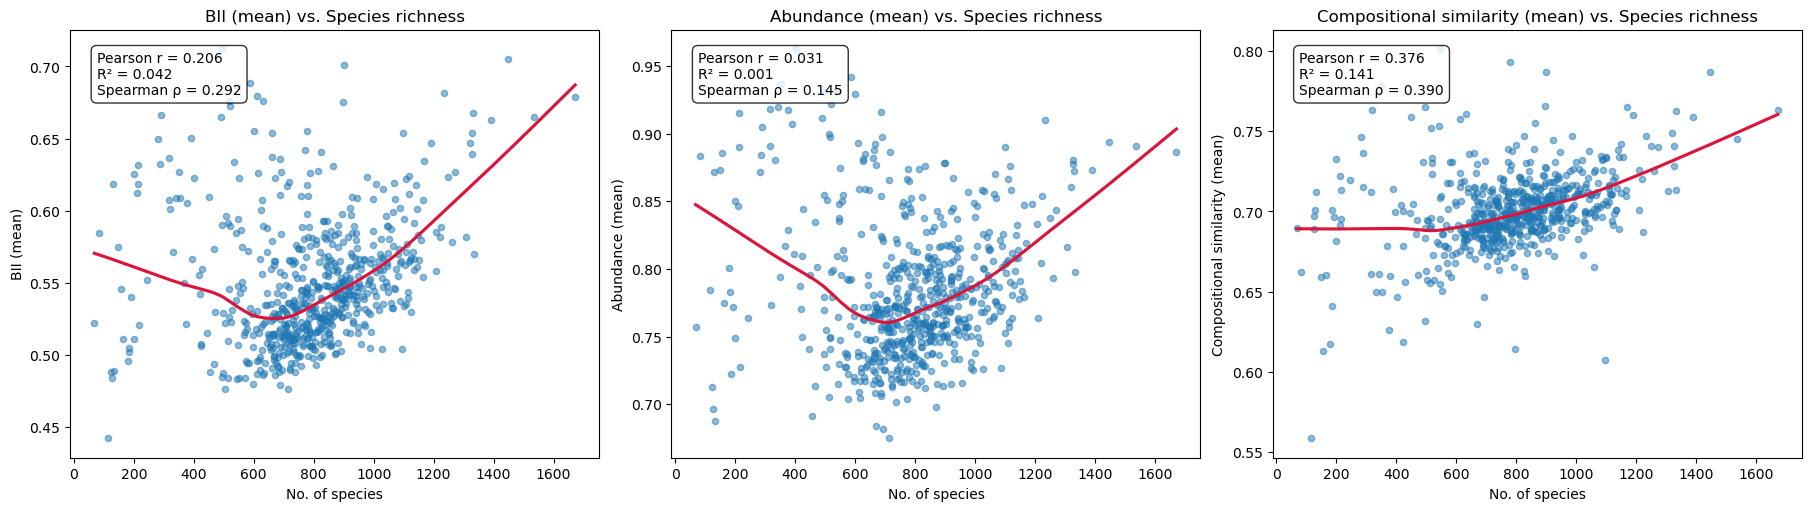

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # make sure this is imported

version = "Richness_v2"  # or "Richness_v1"

cols = [version, "bii_mean", "ab_mean", "cd_mean"]

# Ensure numeric types (coerce any stray strings like '668' or 'NA')
grid_numeric = gridcell_dnk[cols].apply(pd.to_numeric, errors="coerce")

# Drop rows with missing values in any of the needed columns
df = grid_numeric.dropna().copy()

def annotate_stats(ax, x, y):
    # Pearson
    r_p = np.corrcoef(x, y)[0, 1]
    r2  = r_p ** 2
    # Spearman
    rho = pd.DataFrame({x.name: x, y.name: y}).corr(method="spearman").iloc[0, 1]
    text = (f"Pearson r = {r_p:.3f}\n"
            f"R² = {r2:.3f}\n"
            f"Spearman ρ = {rho:.3f}")
    ax.text(0.05, 0.95, text, transform=ax.transAxes,
            fontsize=10, va="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, ycol, label in zip(
    axes,
    ["bii_mean", "ab_mean", "cd_mean"],
    ["BII (mean)", "Abundance (mean)", "Compositional similarity (mean)"]
):
    sns.regplot(
        data=df, x=version, y=ycol, ax=ax,
        scatter_kws={"s": 20, "alpha": 0.5},
        line_kws={"color": "crimson"},
        lowess=True  # smooth LOWESS instead of linear
    )
    ax.set_title(f"{label} vs. Species richness")
    ax.set_xlabel("No. of species")
    ax.set_ylabel(label)
    annotate_stats(ax, df[version], df[ycol])

plt.show()

In [51]:
grid_numeric

,Richness_v2,bii_mean,ab_mean,cd_mean
0,668.0,0.564845,0.892632,0.629873
1,814.0,0.627416,0.873848,0.713155
2,717.0,0.619669,0.886071,0.698980
3,1064.0,0.599186,0.855166,0.697610
4,935.0,0.589538,0.814397,0.720516
...,...,...,...,...
628,870.0,0.500657,0.697711,0.715768
629,688.0,0.557616,0.824298,0.677833
630,526.0,0.531442,0.798895,0.657328
631,941.0,0.540987,0.755459,0.711774


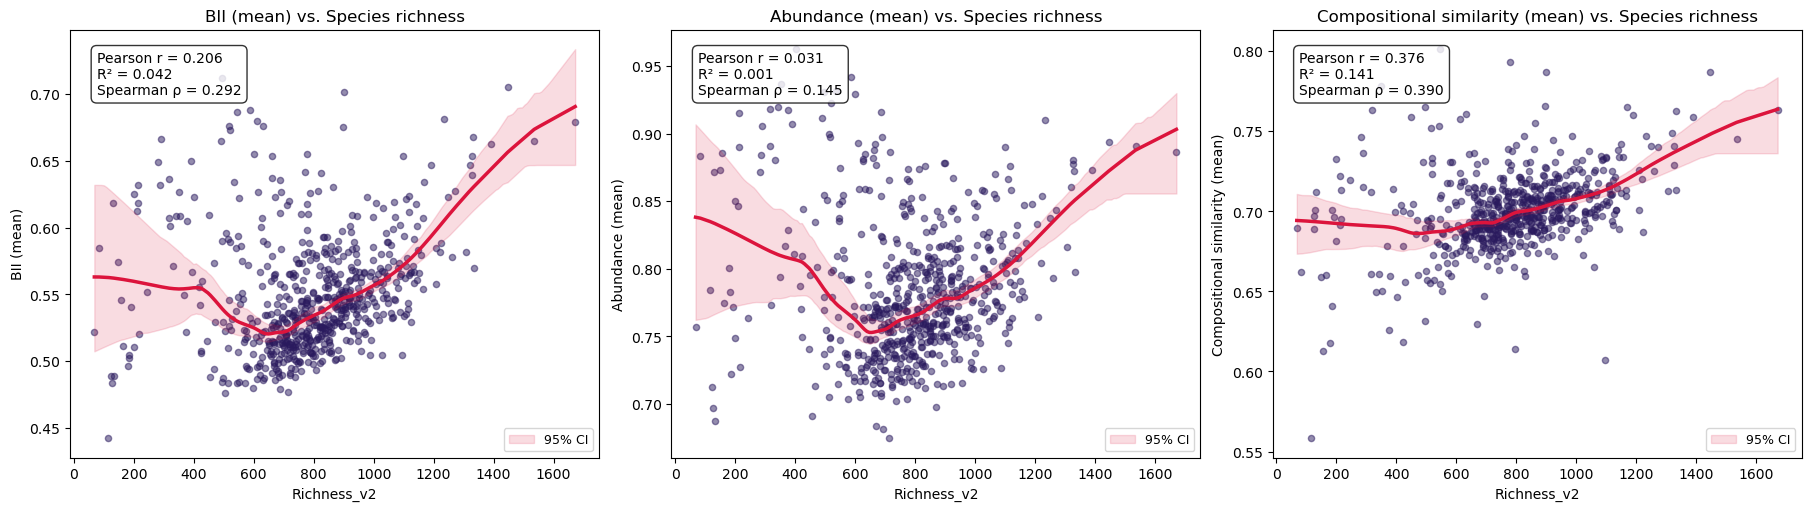

In [52]:
# For a more robust LOWESS with bootstrapped confidence intervals, we can implement it manually:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

version = "Richness_v2" # Richness_v1

cols = [version, "bii_mean", "ab_mean", "cd_mean"]
dfx[cols] = grid_numeric[cols].apply(pd.to_numeric, errors="coerce")
dfx = dfx.dropna(subset=cols)

def bootstrap_lowess(x, y, n_boot=200, frac=0.3, num_points=200):
    """Compute LOWESS with bootstrapped confidence intervals."""
    x_grid = np.linspace(x.min(), x.max(), num_points)
    boot_curves = np.zeros((n_boot, num_points))

    for b in range(n_boot):
        idx = np.random.choice(len(x), size=len(x), replace=True)
        xb, yb = x[idx], y[idx]
        smooth = lowess(yb, xb, frac=frac, return_sorted=True)
        boot_curves[b] = np.interp(x_grid, smooth[:, 0], smooth[:, 1])

    mean_curve = np.mean(boot_curves, axis=0)
    ci_lo = np.percentile(boot_curves, 2.5, axis=0)
    ci_hi = np.percentile(boot_curves, 97.5, axis=0)
    return x_grid, mean_curve, ci_lo, ci_hi

def annotate_stats(ax, x, y):
    r_p = np.corrcoef(x, y)[0, 1]
    r2  = r_p ** 2
    rho, _ = spearmanr(x, y)
    text = (f"Pearson r = {r_p:.3f}\n"
            f"R² = {r2:.3f}\n"
            f"Spearman ρ = {rho:.3f}")
    ax.text(0.05, 0.95, text, transform=ax.transAxes,
            fontsize=10, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, ycol, label in zip(axes, ["bii_mean", "ab_mean", "cd_mean"],
                                  ["BII (mean)", "Abundance (mean)", "Compositional similarity (mean)"]):
    x = dfx[version].values
    y = dfx[ycol].values

    # scatter
    # ax.scatter(x, y, s=20, alpha=0.5, color="steelblue")
    ax.scatter(x, y, s=20, alpha=0.5, color="#2A1A5E")

    # bootstrapped LOWESS + 95% CI
    xg, mu, ci_lo, ci_hi = bootstrap_lowess(x, y, n_boot=200, frac=0.3)
    ax.plot(xg, mu, color="crimson", lw=2.5)
    ax.fill_between(xg, ci_lo, ci_hi, color="crimson", alpha=0.15, label="95% CI")

    ax.set_title(f"{label} vs. Species richness")
    ax.set_xlabel(version)
    ax.set_ylabel(label)
    ax.legend(loc="lower right", fontsize=9)
    annotate_stats(ax, x, y)

plt.show()

In [55]:
gridcell_dnk.columns

Index(['OBJECTID', 'UTM_ZONE_C', 'WORLDMAP_C', 'LANDAREAL_', 'WMnr',
       'WORLDMAP_C_1', 'Richness_v1', 'Shape_Length', 'Shape_Area',
       'Richness_v2', 'Rare-quartile', 'geometry'],
      dtype='object')

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress

# --- CONFIG ---
version = "Richness_v2"
preds = ["bii_mean", "ab_mean", "cd_mean"]

# --- SELECT & CLEAN DATA ---
cols = [version] + preds
dfx = gridcell_dnk[cols].copy()

# force numeric (fix dtype('O'))
for c in cols:
    dfx[c] = (
        dfx[c]
        .astype(str)
        .str.replace(",", "")
        .str.strip()
    )
    dfx[c] = pd.to_numeric(dfx[c], errors="coerce")

dfx = (
    dfx
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=cols)
)

# --- SET UP FIGURE ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

x = dfx[version].to_numpy(dtype=float)

for ax, pred in zip(axes, preds):
    y = dfx[pred].to_numpy(dtype=float)

    # sanity checks
    if len(x) < 3 or np.isclose(np.var(x), 0):
        ax.set_title(f"{pred} (insufficient data)")
        continue

    # regression
    slope, intercept, r_val, p_val, _ = linregress(x, y)

    # regression line
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept

    # CI / PI
    n = len(x)
    x_mean = x.mean()
    y_pred = slope * x + intercept
    resid_se = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))
    Sxx = np.sum((x - x_mean)**2)

    se_line = resid_se * np.sqrt(1/n + (x_line - x_mean)**2 / Sxx)
    pi = resid_se * np.sqrt(1 + 1/n + (x_line - x_mean)**2 / Sxx)

    # plot
    ax.scatter(x, y, s=18, alpha=0.5, color="#2A1A5E")
    ax.plot(x_line, y_line, lw=2.5, color="crimson", label="Linear fit")

    ax.fill_between(
        x_line,
        y_line - 1.96 * se_line,
        y_line + 1.96 * se_line,
        color="crimson",
        alpha=0.15,
        label="95% CI (mean)"
    )

    ax.fill_between(
        x_line,
        y_line - 1.96 * pi,
        y_line + 1.96 * pi,
        color="grey",
        alpha=0.1,
        label="95% PI"
    )

    # stats
    rho, _ = spearmanr(x, y)
    txt = (
        f"y = {slope:.4f}x + {intercept:.3f}\n"
        f"Pearson r = {r_val:.3f}\n"
        f"R² = {r_val**2:.3f}\n"
        f"Spearman ρ = {rho:.3f}\n"
        f"p = {p_val:.2e}"
    )

    ax.text(
        0.95, 0.05, txt,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4",
                  facecolor="white", alpha=0.8)
    )

    ax.set_title(f"{pred} vs. {version}")
    ax.set_ylabel(pred)

axes[0].set_xlabel(version)
axes[1].set_xlabel(version)
axes[2].set_xlabel(version)

axes[2].legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

KeyError: "['bii_mean', 'ab_mean', 'cd_mean'] not in index"

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, linregress

version = "Richness_v2" # Richness_v1
pred = "bii_mean" # bii_mean, cd_mean

# Start from the two columns
dfx = gridcell_dnk[[version, pred]].copy()

# ---- FIX: ensure numeric, drop invalid ----
# If the column might include commas/spaces, normalize first
s = dfx[version].astype(str).str.replace(",", "").str.strip()
dfx[version] = pd.to_numeric(s, errors="coerce")
dfx[pred] = pd.to_numeric(dfx[pred], errors="coerce")
dfx = dfx.replace([np.inf, -np.inf], np.nan).dropna(subset=[version, pred])

# Extract numeric arrays
x = dfx[version].to_numpy(dtype=float)
y = dfx[pred].to_numpy(dtype=float)

# Sanity checks
if len(x) < 3:
    raise ValueError(f"Not enough valid rows after cleaning: n={len(x)}")
if np.isclose(np.var(x), 0):
    raise ValueError("Cannot run linear regression: all x values are identical (zero variance).")

# ---- Your regression and plot ----
slope, intercept, r_val, p_val, std_err = linregress(x, y)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, s=20, alpha=0.5, color="#2A1A5E")

x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

n = len(x)
x_mean = x.mean()
y_pred = slope * x + intercept
resid_se = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))
Sxx = np.sum((x - x_mean)**2)
se_line = resid_se * np.sqrt(1/n + (x_line - x_mean)**2 / Sxx)

ax.plot(x_line, y_line, color="crimson", lw=2.5, label="Linear fit")
ax.fill_between(x_line, y_line - 1.96*se_line, y_line + 1.96*se_line,
                color="crimson", alpha=0.15, label="95% CI (mean)")

# Optional: prediction interval
pi = resid_se * np.sqrt(1 + 1/n + (x_line - x_mean)**2 / Sxx)
ax.fill_between(x_line, y_line - 1.96*pi, y_line + 1.96*pi,
                color="grey", alpha=0.1, label="95% PI (prediction)")

rho, _ = spearmanr(x, y)
text = (f"y = {slope:.5f}x + {intercept:.3f}\n"
        f"Pearson r = {r_val:.3f}\n"
        f"R² = {r_val**2:.3f}\n"
        f"Spearman ρ = {rho:.3f}\n"
        f"p = {p_val:.2e}")
# ax.text(0.05, 0.95, text, transform=ax.transAxes, fontsize=10,
#         va="top", bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))
ax.text(0.95, 0.05, text, transform=ax.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

ax.set_xlabel(version)
ax.set_ylabel("BII (mean)")
ax.set_title(f"BII vs. {version} — Linear model")
ax.legend(loc="lower center")
plt.tight_layout()
plt.show()

KeyError: "['bii_mean'] not in index"

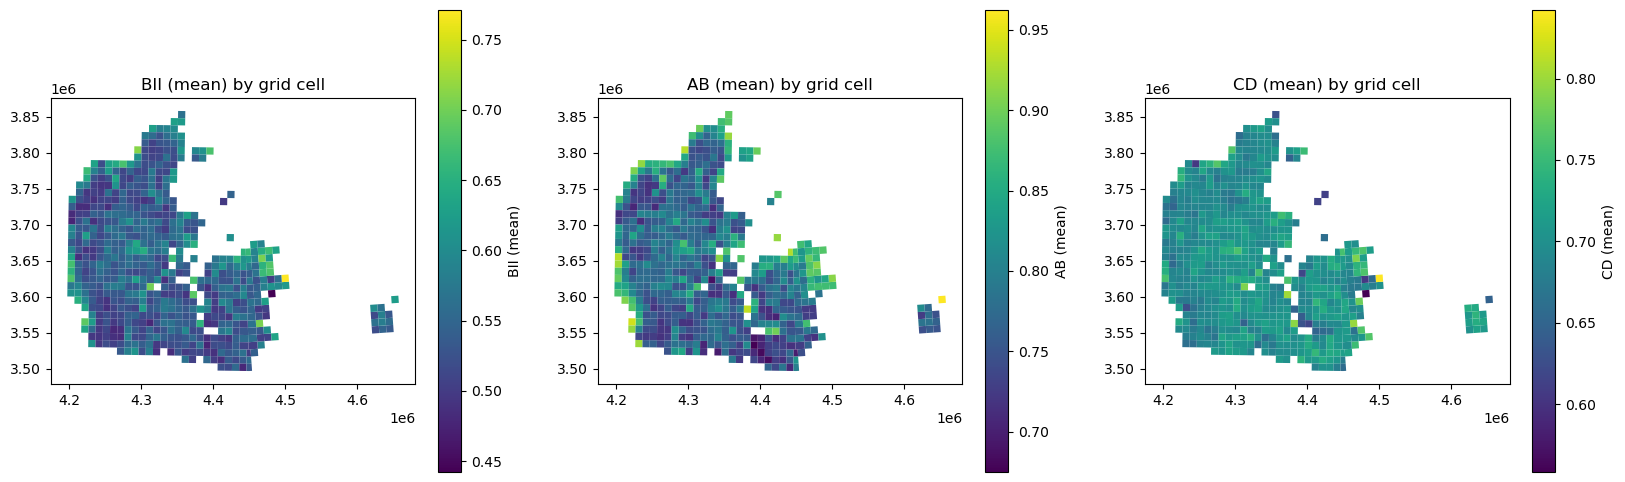

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
gridcell_dnk.plot(column="bii_mean", cmap="viridis", legend=True,
                  legend_kwds={"label":"BII (mean)"}, ax=ax[0])
ax[0].set_title("BII (mean) by grid cell")

gridcell_dnk.plot(column="ab_mean", cmap="viridis", legend=True,
                  legend_kwds={"label":"AB (mean)"}, ax=ax[1])
ax[1].set_title("AB (mean) by grid cell")
gridcell_dnk.plot(column="cd_mean", cmap="viridis", legend=True,
                  legend_kwds={"label":"CD (mean)"}, ax=ax[2])
ax[2].set_title("CD (mean) by grid cell")
plt.show()

In [ ]:
# # Save enriched grid with stats
# out_gpkg = base / "Validation/gridcell_dnk_with_bii_ab.gpkg"
# gridcell_dnk.to_file(out_gpkg, driver="GPKG")

# # Also a flat table if you want to use it in R/Excel
# gridcell_dnk.drop(columns="geometry").to_csv(base / "Validation/gridcell_dnk_bii_ab.csv", index=False)

## Gridcell comp to LUI

In [29]:
import geopandas as gpd
import rioxarray as rxr
from pathlib import Path

# Vector grid (has 'No_of_species')
gridcell_dnk = gpd.read_file(base / "Validation/gridcell_dnk_v2.gpkg")
gridcell_dnk = gridcell_dnk.rename(columns={
    "No_of_species": "Richness_v1",
    "Richness": "Richness_v2"
})

# Rasters (rioxarray)
lui_18  = rxr.open_rasterio(base / "BII_LU_layer/Land_use_map/v7/lu_intensity_dnk_2018_v7.tif").squeeze()
lui_23  = rxr.open_rasterio(base / "BII_LU_layer/Land_use_map/v7/lu_intensity_dnk_2023_v7.tif").squeeze()


# Make sure rasters share the same CRS
assert bii_da.rio.crs == lui_18.rio.crs, "BII and AB rasters have different CRS!"
assert bii_da.rio.crs == lui_23.rio.crs, "BII and CD rasters have different CRS!"

# Reproject grid to the raster CRS (if needed)
if gridcell_dnk.crs != lui_18.rio.crs:
    gridcell_dnk = gridcell_dnk.to_crs(lui_18.rio.crs)

In [30]:
from rasterstats import zonal_stats
import numpy as np
import pandas as pd

# ── LUI class lookup ──
INTENSITY_CLASSES = {
    'urban_minimal': 10, 'urban_light': 11, 'urban_intense': 12,
    'plantation_minimal': 30, 'plantation_light': 31, 'plantation_intense': 32,
    'pasture_minimal': 60, 'pasture_light': 61, 'pasture_intense': 62,
    'crop_minimal': 70, 'crop_light': 71, 'crop_intense': 72,
    'sv_mature_minimal': 210, 'sv_mature_light': 211, 'sv_mature_intense': 212,
    'sv_intermediate_minimal': 220, 'sv_intermediate_light': 221, 'sv_intermediate_intense': 222,
    'sv_young_minimal': 230, 'sv_young_light': 231, 'sv_young_intense': 232,
    'sv_indeterminate_minimal': 240, 'sv_indeterminate_light': 241, 'sv_indeterminate_intense': 242,
}
REVERSE = {v: k for k, v in INTENSITY_CLASSES.items()}


# ── Calculate proportions per grid cell ──
def calc_lui_proportions(gdf, raster_path, suffix=""):
    stats = zonal_stats(
        gdf.geometry,
        str(raster_path),
        categorical=True,
        nodata=255,
    )
    rows = []
    for cell_stats in stats:
        total = sum(cell_stats.values())
        props = {}
        for val, name in REVERSE.items():
            count = cell_stats.get(val, 0)
            props[f"{name}{suffix}"] = count / total if total > 0 else np.nan
        rows.append(props)
    return pd.DataFrame(rows)


# ── Reload clean grid to avoid duplicate columns from reruns ──
gridcell_dnk = gpd.read_file(base / "Validation/gridcell_dnk_v2.gpkg")
gridcell_dnk = gridcell_dnk.rename(columns={
    "No_of_species": "Richness_v1",
    "Richness": "Richness_v2"
})
if gridcell_dnk.crs != lui_18.rio.crs:
    gridcell_dnk = gridcell_dnk.to_crs(lui_18.rio.crs)


# ── Run for both years ──
props_18 = calc_lui_proportions(
    gridcell_dnk,
    base / "BII_LU_layer/Land_use_map/v1/lu_intensity_dnk_2018_v1.tif",
    "_2018"
)
props_23 = calc_lui_proportions(
    gridcell_dnk,
    base / "BII_LU_layer/Land_use_map/v1/lu_intensity_dnk_2023_v1.tif",
    "_2023"
)

gridcell_dnk = pd.concat(
    [gridcell_dnk.reset_index(drop=True), props_18, props_23], axis=1
)


# ── Aggregate to broader land-use types ──
lu_types = ["urban", "crop", "pasture", "plantation",
            "sv_mature", "sv_intermediate", "sv_young", "sv_indeterminate"]

for yr in ["2018", "2023"]:
    for lu in lu_types:
        cols = [f"{lu}_minimal_{yr}", f"{lu}_light_{yr}", f"{lu}_intense_{yr}"]
        gridcell_dnk[f"{lu}_total_{yr}"] = gridcell_dnk[cols].sum(axis=1)


# ── Compare with richness ──
lui_cols = [c for c in gridcell_dnk.columns if c.endswith(("_total_2018", "_total_2023"))]

# Numeric correlation
numeric_cols = ["Richness_v1", "Richness_v2"]
corr_df = gridcell_dnk[numeric_cols + lui_cols].apply(pd.to_numeric, errors="coerce")
print("=== Correlations with Richness ===")
print(corr_df.corr()[numeric_cols].drop(numeric_cols).round(3))

# Categorical breakdown
print("\n=== Mean LUI proportions by Rare-quartile ===")
print(
    gridcell_dnk.groupby("Rare-quartile")[lui_cols]
    .mean()
    .T.round(4)
)

=== Correlations with Richness ===
                             Richness_v1  Richness_v2
urban_total_2018                   0.470        0.474
crop_total_2018                    0.283        0.342
pasture_total_2018                 0.227        0.296
plantation_total_2018              0.531        0.524
sv_mature_total_2018               0.681        0.630
sv_intermediate_total_2018         0.539        0.531
sv_young_total_2018                0.435        0.433
sv_indeterminate_total_2018        0.023        0.010
urban_total_2023                   0.476        0.478
crop_total_2023                    0.276        0.339
pasture_total_2023                 0.273        0.333
plantation_total_2023              0.527        0.520
sv_mature_total_2023               0.674        0.624
sv_intermediate_total_2023         0.522        0.515
sv_young_total_2023                0.418        0.407
sv_indeterminate_total_2023        0.022        0.010

=== Mean LUI proportions by Rare-quartile ===


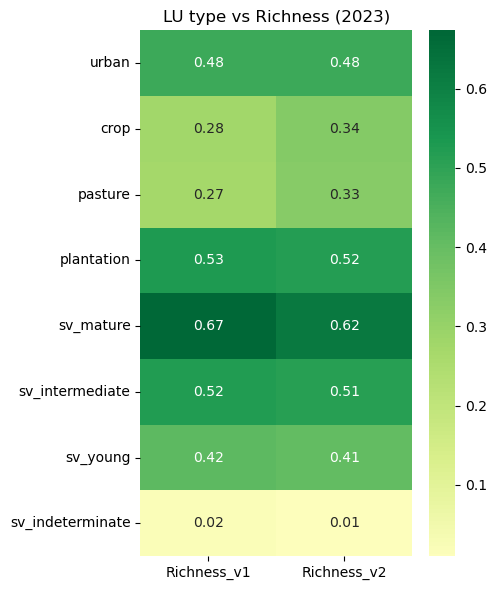

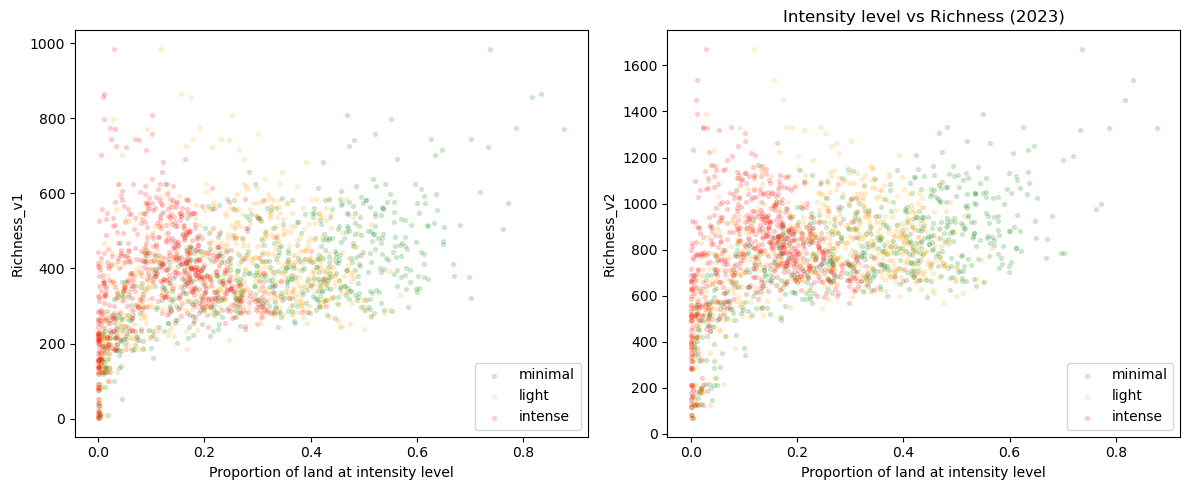

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

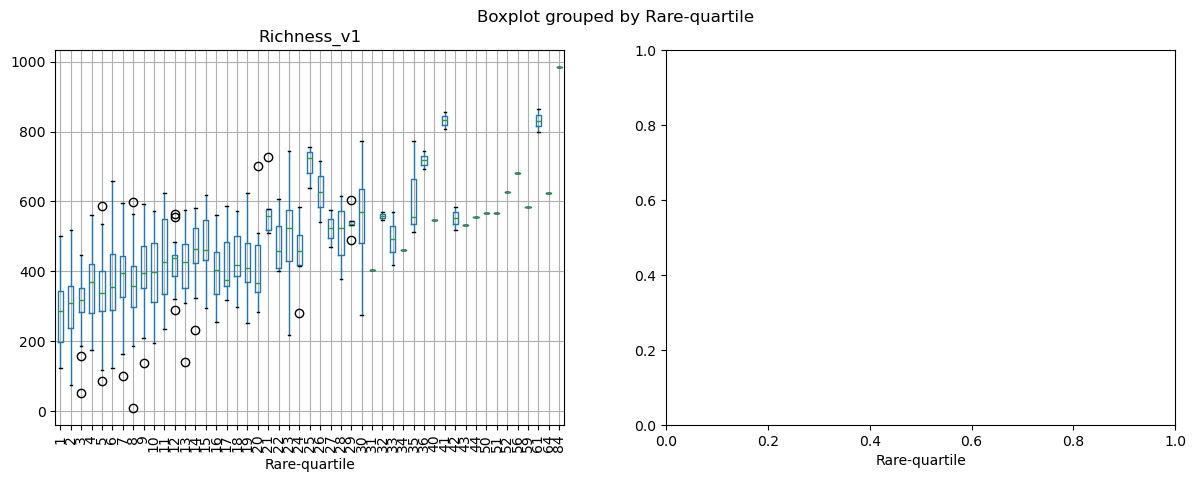

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

yr = "2023"  # pick one year, or loop both

# ── 1) Correlation heatmap: LU totals vs Richness ──
lui_cols = [c for c in gridcell_dnk.columns if c.endswith(f"_total_{yr}")]
corr = gridcell_dnk[["Richness_v1", "Richness_v2"] + lui_cols].apply(
    pd.to_numeric, errors="coerce"
).corr()[["Richness_v1", "Richness_v2"]].drop(["Richness_v1", "Richness_v2"])
corr.index = corr.index.str.replace(f"_total_{yr}", "")

fig, ax = plt.subplots(figsize=(5, 6))
sns.heatmap(corr, annot=True, cmap="RdYlGn", center=0, fmt=".2f", ax=ax)
ax.set_title(f"LU type vs Richness ({yr})")
plt.tight_layout()
plt.show()


# ── 2) Intensity breakdown vs Richness ──
# Aggregate across ALL LU types by intensity level
for level in ["minimal", "light", "intense"]:
    cols = [c for c in gridcell_dnk.columns if f"_{level}_{yr}" in c]
    gridcell_dnk[f"all_{level}_{yr}"] = gridcell_dnk[cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, rich in zip(axes, ["Richness_v1", "Richness_v2"]):
    for level, color in zip(["minimal", "light", "intense"], ["green", "orange", "red"]):
        ax.scatter(
            gridcell_dnk[f"all_{level}_{yr}"],
            pd.to_numeric(gridcell_dnk[rich], errors="coerce"),
            alpha=0.15, s=8, label=level, color=color
        )
    ax.set_xlabel("Proportion of land at intensity level")
    ax.set_ylabel(rich)
    ax.legend()
ax.set_title(f"Intensity level vs Richness ({yr})")
plt.tight_layout()
plt.show()


# Convert Rare-quartile to numeric for proper sorting
gridcell_dnk["Rare-quartile"] = pd.to_numeric(gridcell_dnk["Rare-quartile"], errors="coerce").astype("Int64")

# ── Boxplots (plot 3) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, rich in zip(axes, ["Richness_v1", "Richness_v2"]):
    sorted_df = gridcell_dnk.sort_values("Rare-quartile")
    sorted_df.boxplot(column=rich, by="Rare-quartile", ax=ax, rot=90)
    ax.set_title(rich)
    ax.set_xlabel("Rare-quartile")
fig.suptitle("")
plt.tight_layout()
plt.show()

# ── Stacked bar: LU composition (plot 4) ──
lu_types = ["urban", "crop", "pasture", "plantation",
            "sv_mature", "sv_intermediate", "sv_young", "sv_indeterminate"]
total_cols = [f"{lu}_total_{yr}" for lu in lu_types]

comp = gridcell_dnk.groupby("Rare-quartile")[total_cols].mean()
comp.columns = lu_types
comp = comp.sort_index()  # now sorts numerically

comp.plot.bar(stacked=True, figsize=(14, 6),
              colormap="Set2", edgecolor="none")
plt.ylabel("Mean proportion")
plt.title(f"Land-use composition by Rare-quartile ({yr})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ── Stacked bar: Intensity composition (plot 5) ──
intensity_cols = [f"all_{level}_{yr}" for level in ["minimal", "light", "intense"]]
comp_int = gridcell_dnk.groupby("Rare-quartile")[intensity_cols].mean()
comp_int.columns = ["minimal", "light", "intense"]
comp_int = comp_int.sort_index()

comp_int.plot.bar(stacked=True, figsize=(14, 5),
                  color=["green", "orange", "red"], edgecolor="none")
plt.ylabel("Mean proportion")
plt.title(f"Intensity composition by Rare-quartile ({yr})")
plt.tight_layout()
plt.show()


# ── 4) Stacked bar: LU composition per Rare-quartile ──
lu_types = ["urban", "crop", "pasture", "plantation",
            "sv_mature", "sv_intermediate", "sv_young", "sv_indeterminate"]
total_cols = [f"{lu}_total_{yr}" for lu in lu_types]

comp = gridcell_dnk.groupby("Rare-quartile")[total_cols].mean()
comp.columns = lu_types
comp = comp.sort_index()

comp.plot.bar(stacked=True, figsize=(14, 6),
              colormap="Set2", edgecolor="none")
plt.ylabel("Mean proportion")
plt.title(f"Land-use composition by Rare-quartile ({yr})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ── 5) Intensity composition per Rare-quartile ──
intensity_cols = [f"all_{level}_{yr}" for level in ["minimal", "light", "intense"]]
comp_int = gridcell_dnk.groupby("Rare-quartile")[intensity_cols].mean()
comp_int.columns = ["minimal", "light", "intense"]

comp_int.plot.bar(stacked=True, figsize=(14, 5),
                  color=["green", "orange", "red"], edgecolor="none")
plt.ylabel("Mean proportion")
plt.title(f"Intensity composition by Rare-quartile ({yr})")
plt.tight_layout()
plt.show()

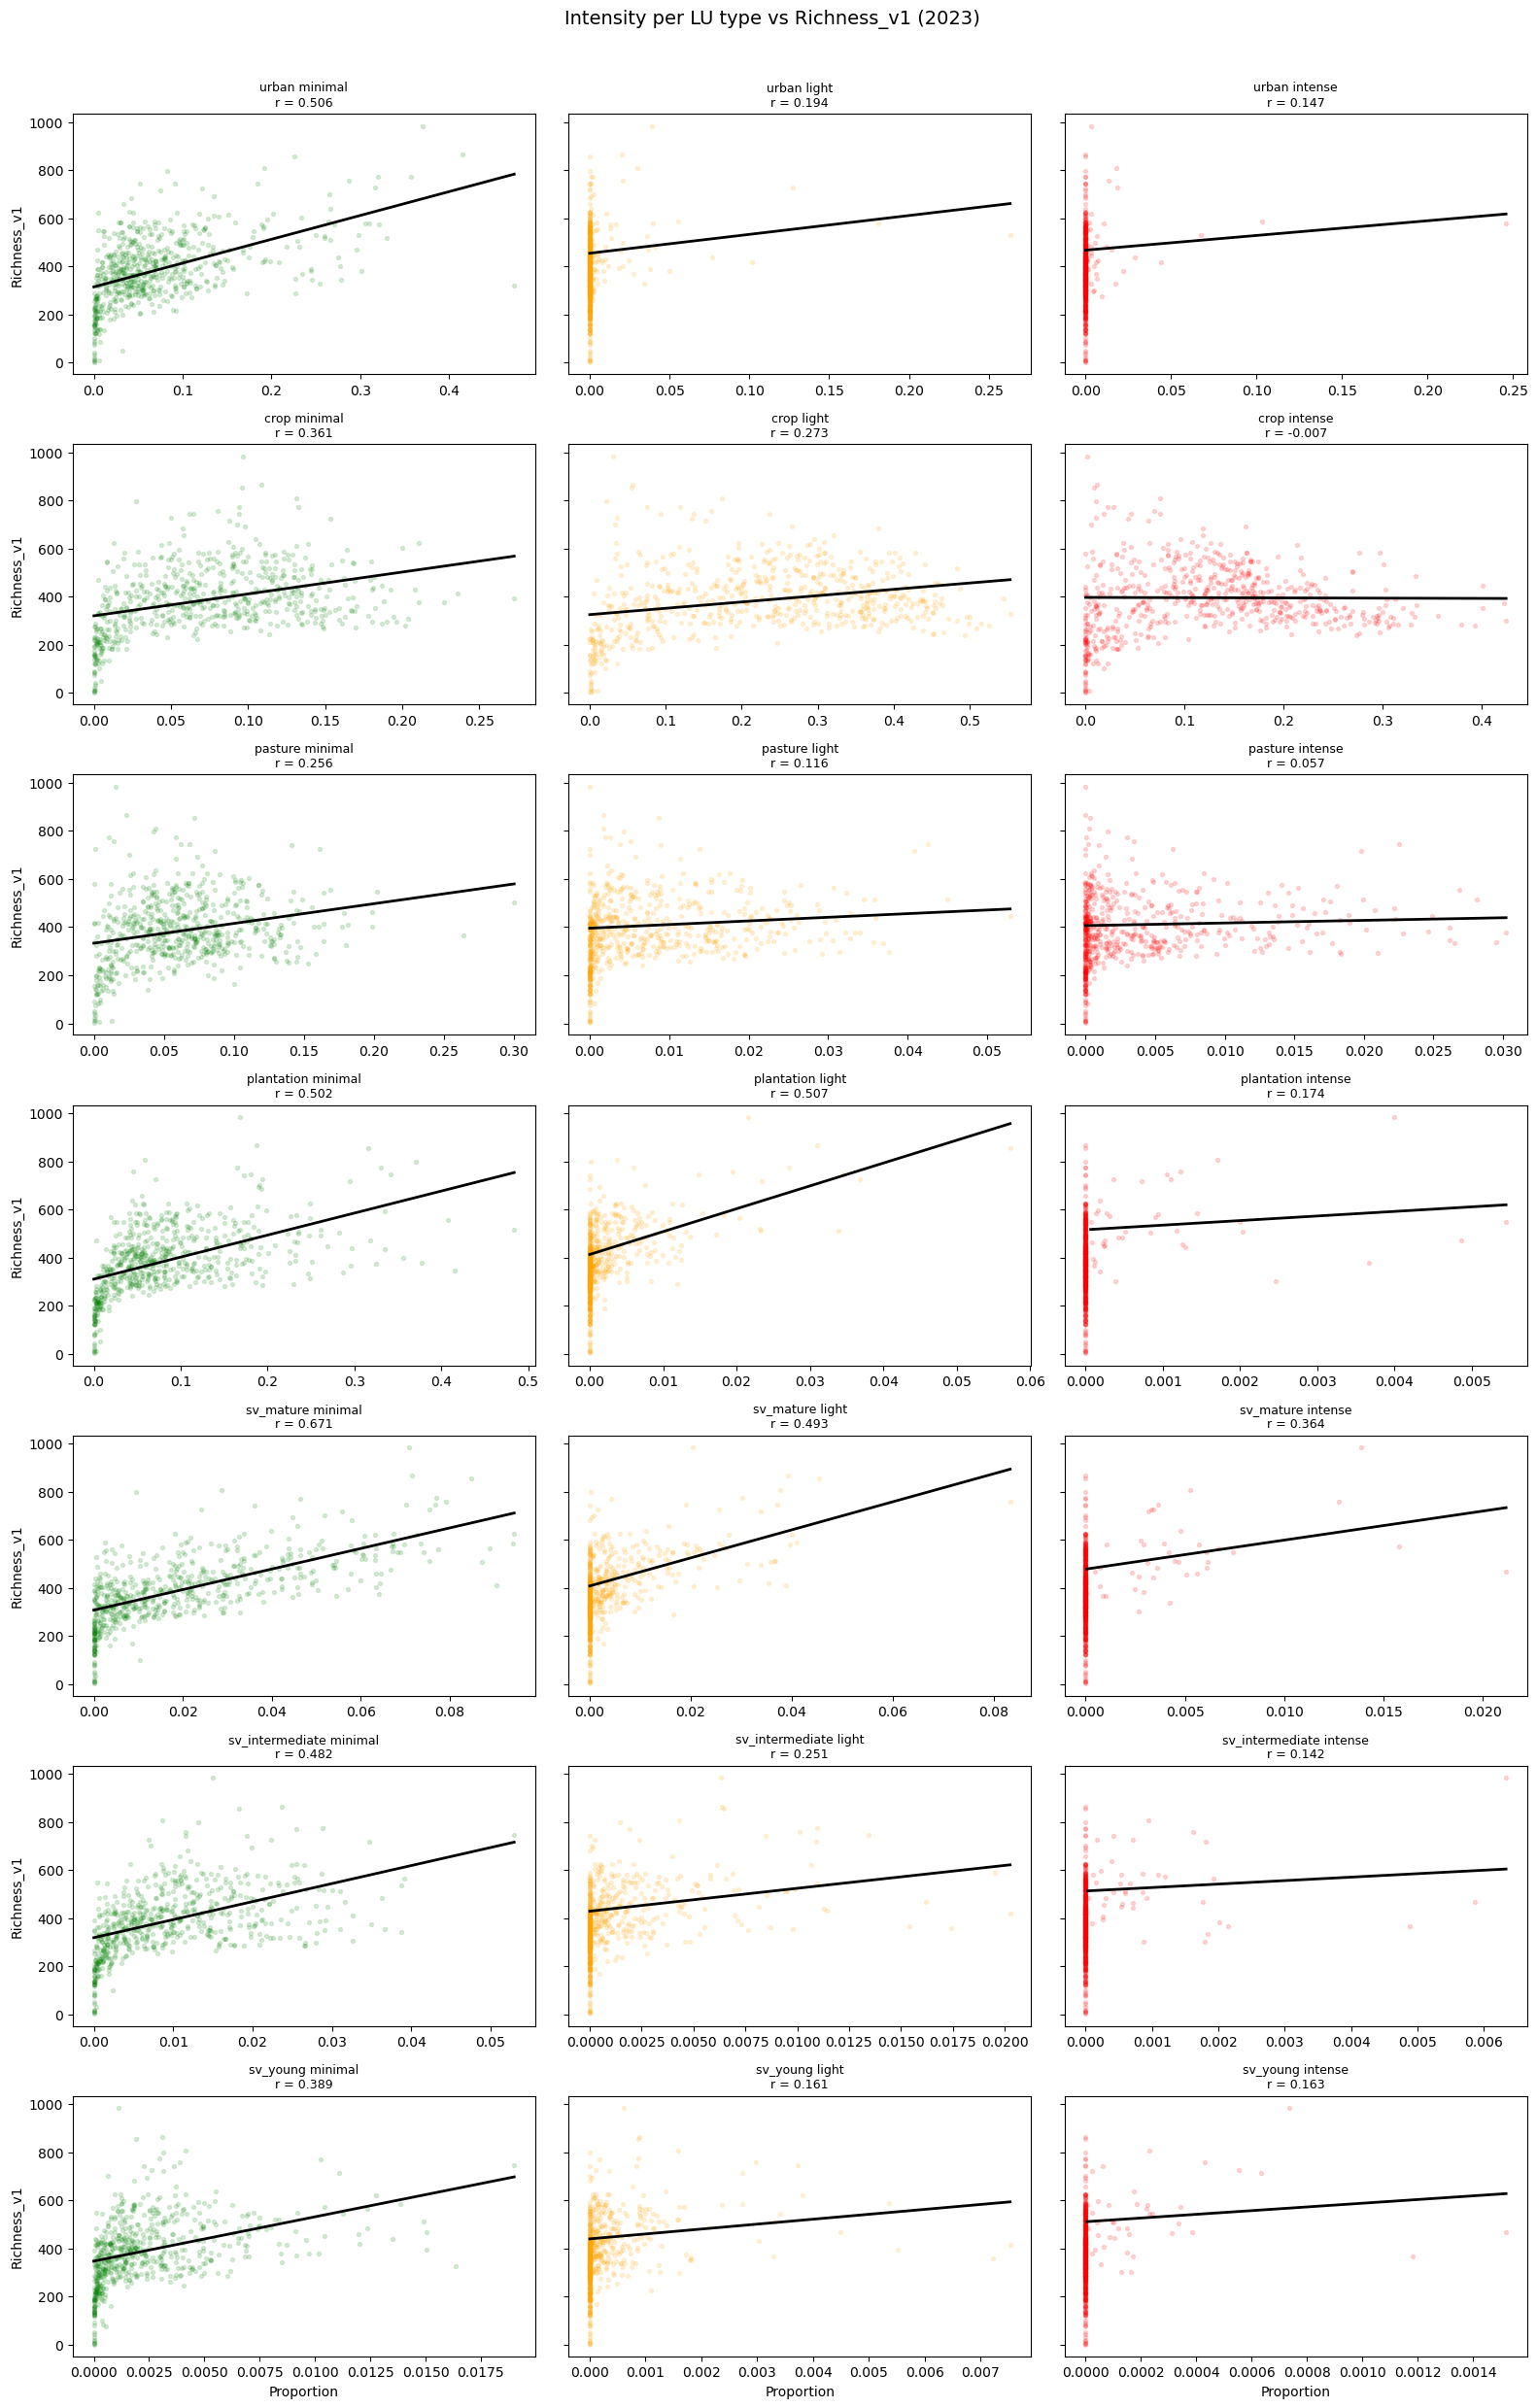

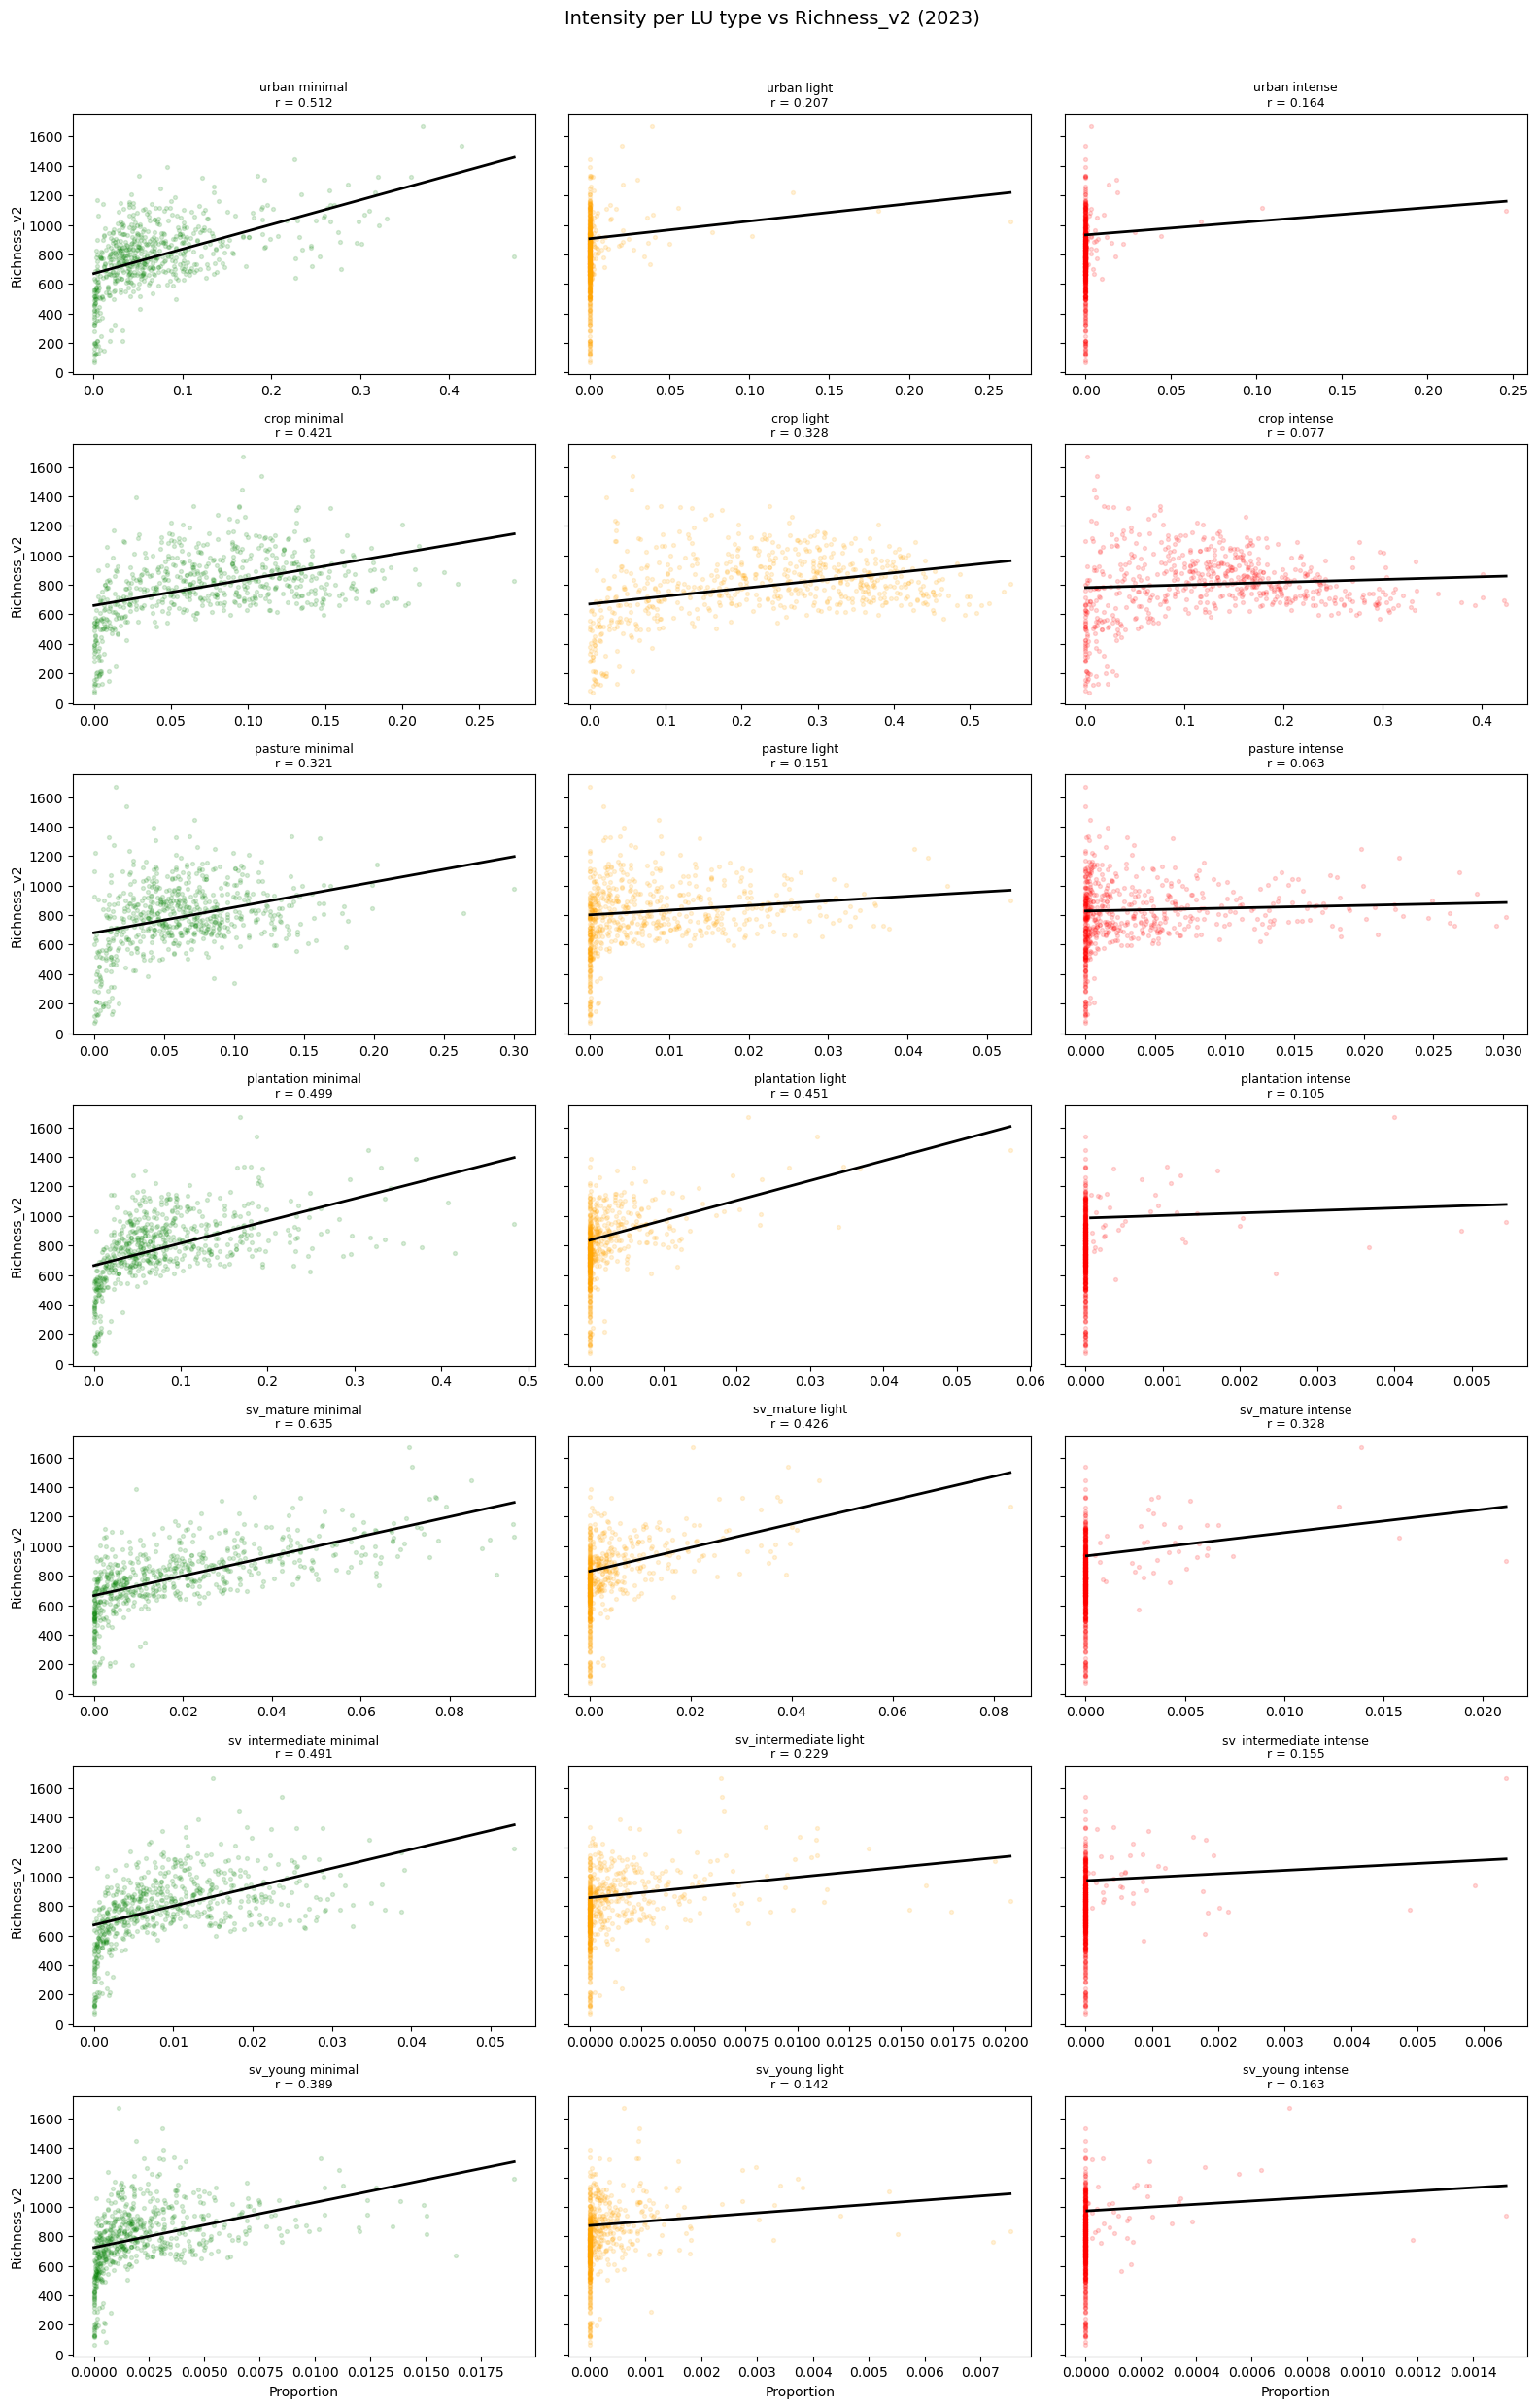

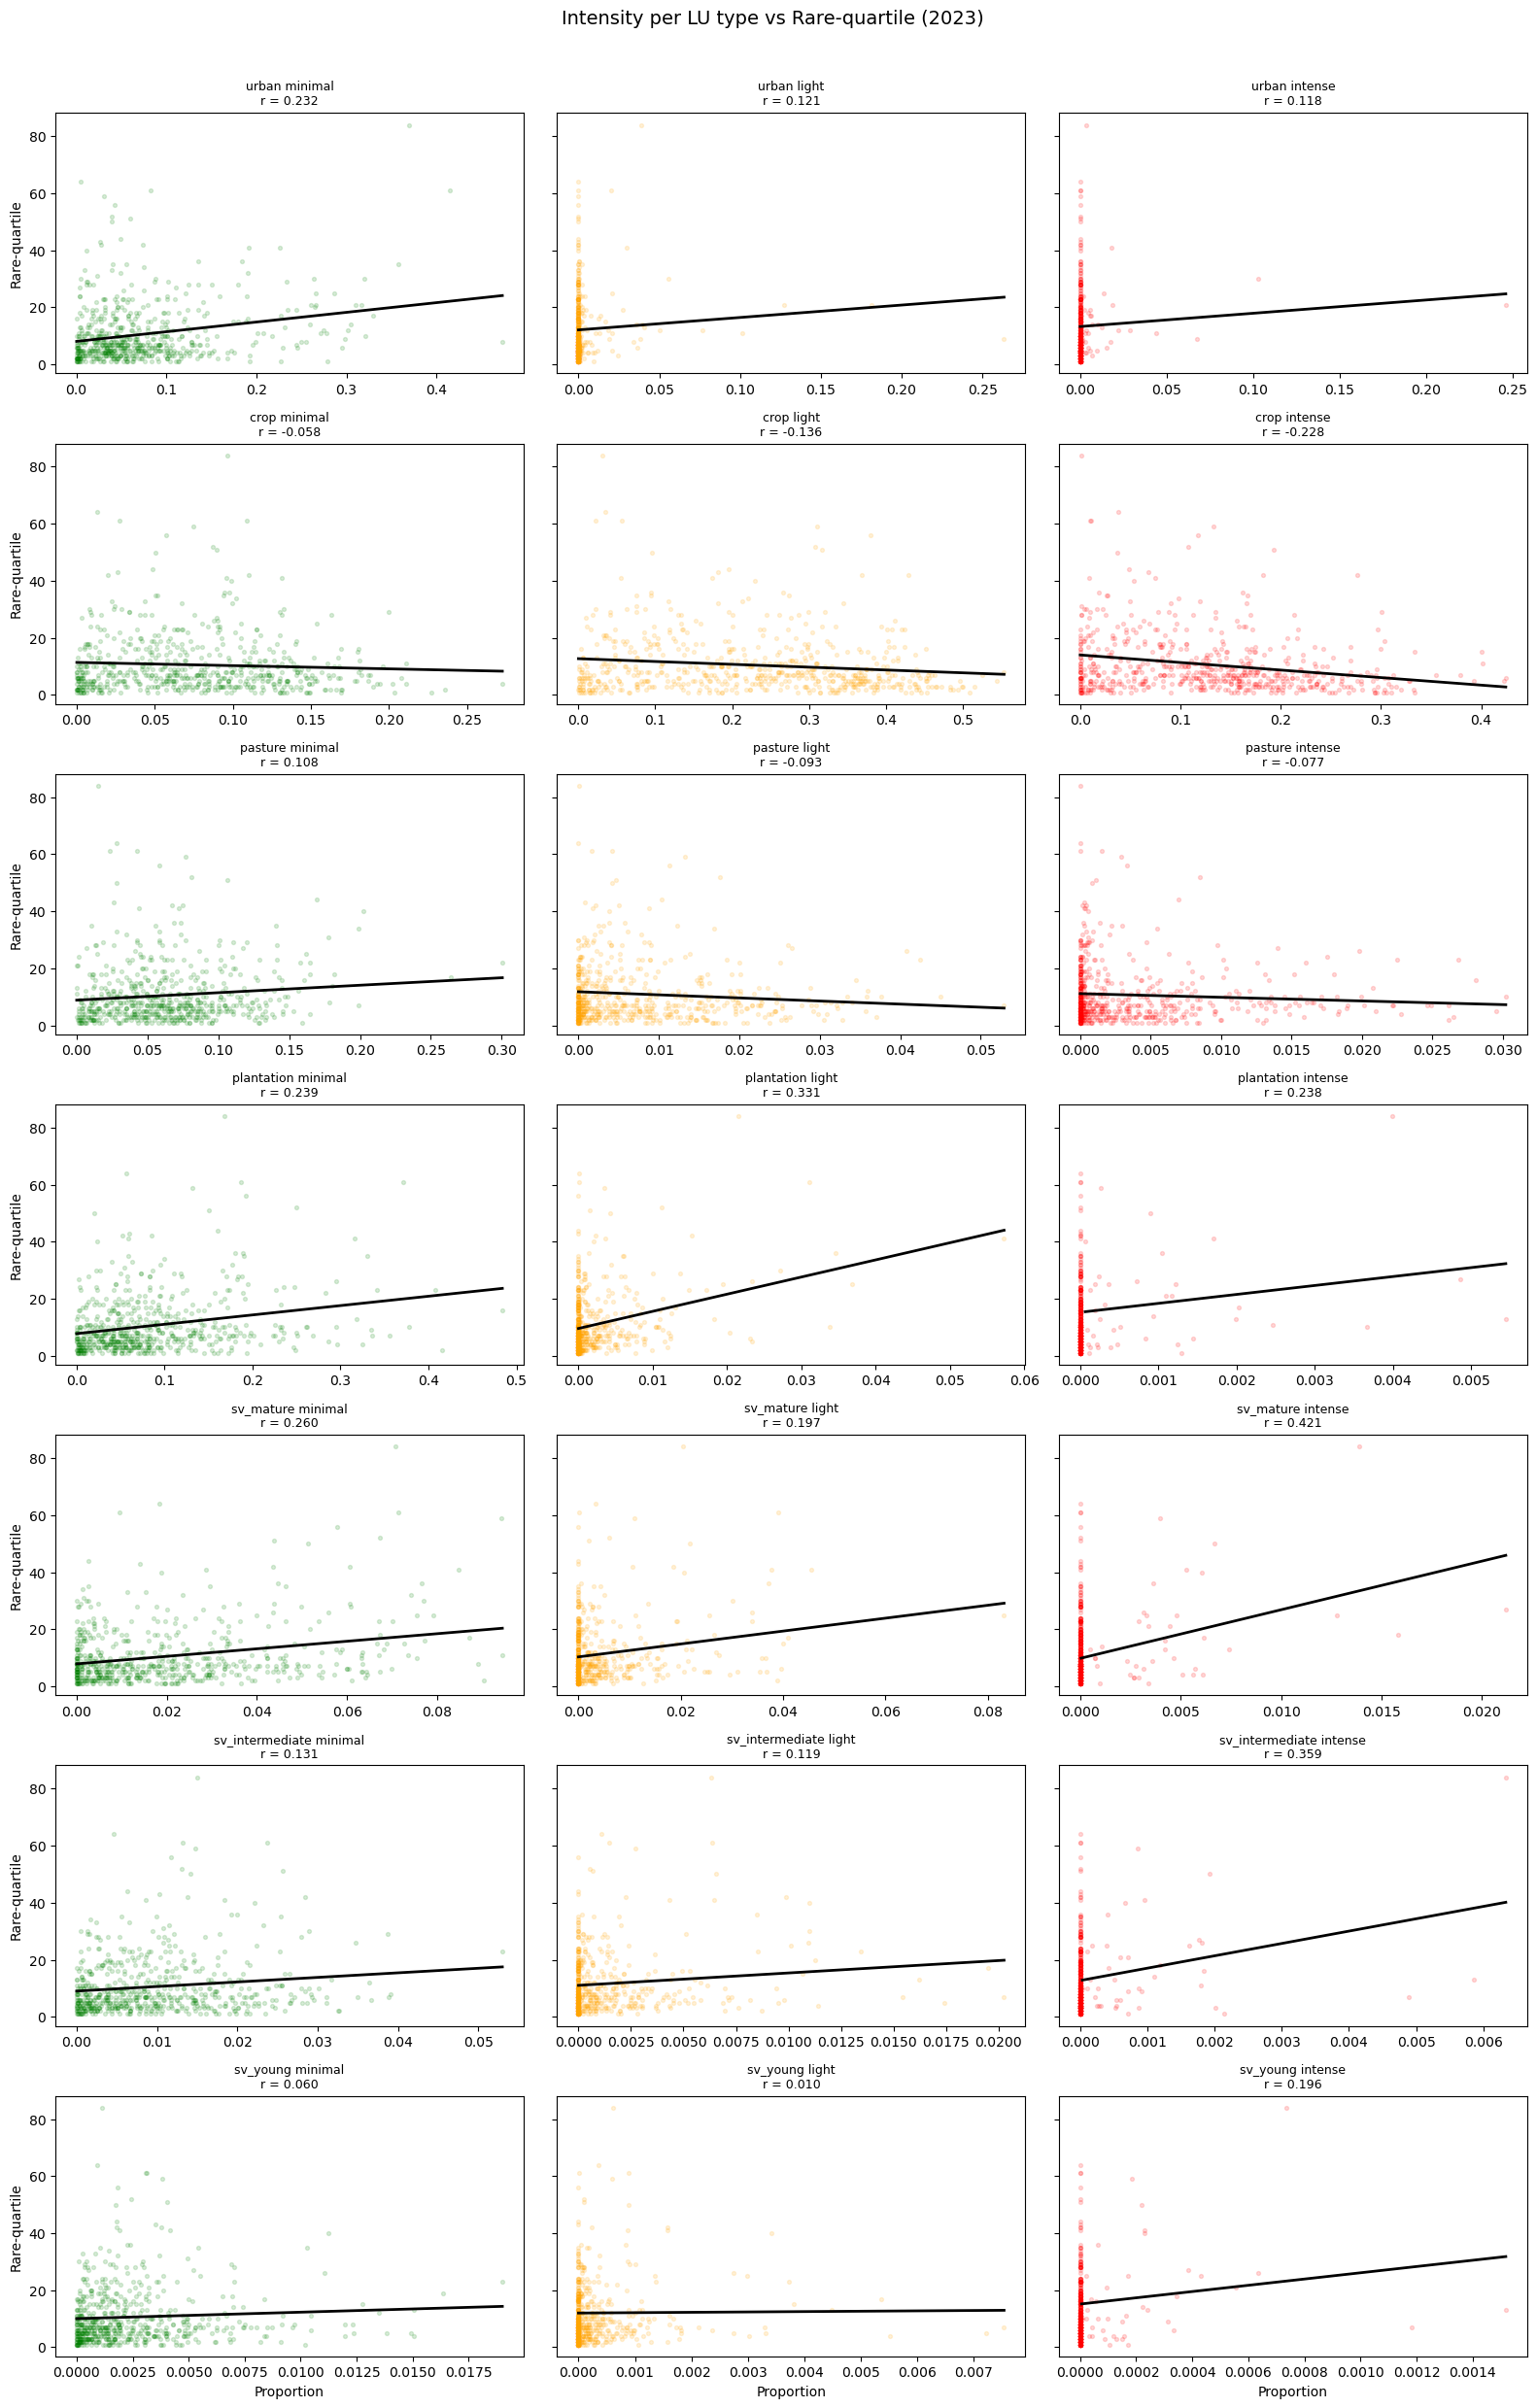


=== Correlation: intensity per LU type vs Richness & Rare-quartile (2023) ===

                 minimal_Richness_v1  minimal_Richness_v2  minimal_Rare-quartile  light_Richness_v1  light_Richness_v2  light_Rare-quartile  intense_Richness_v1  intense_Richness_v2  intense_Rare-quartile
land_use                                                                                                                                                                                                    
urban                          0.508                0.512                  0.232              0.174              0.168                0.094                0.112                0.111                  0.080
crop                           0.389                0.437                 -0.049              0.273              0.328               -0.136                0.115                0.172                 -0.208
pasture                        0.255                0.320                  0.106              0.236 

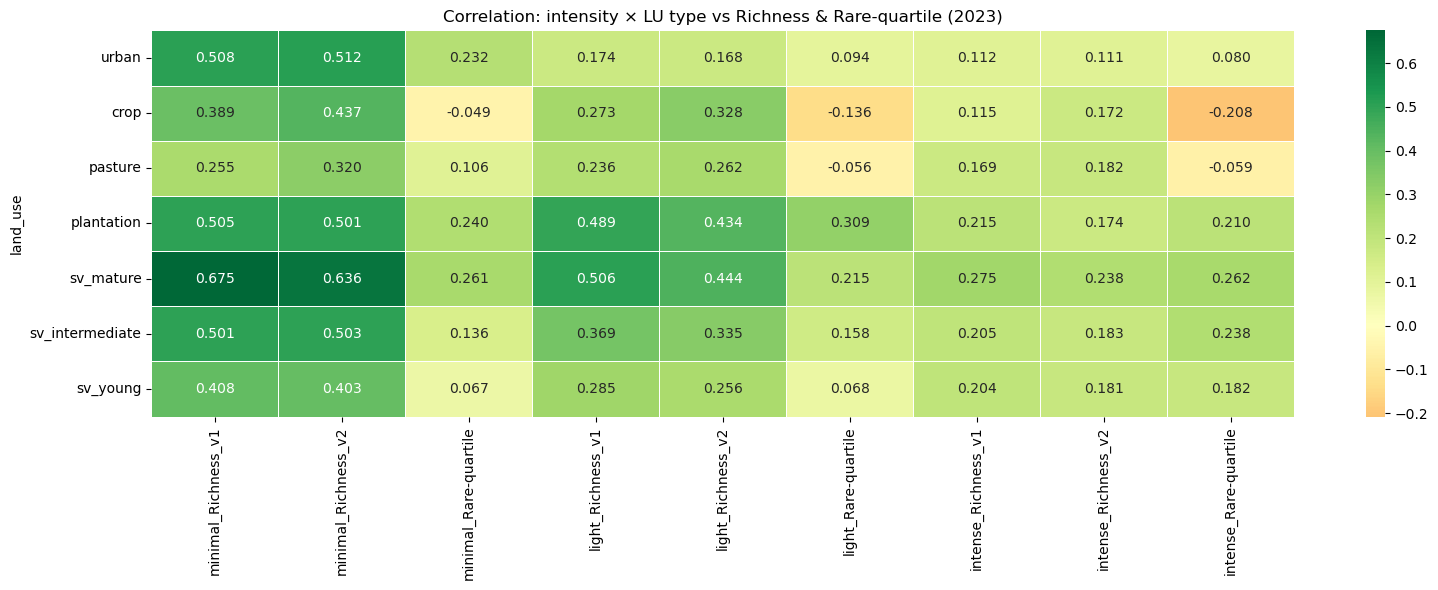

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

yr = "2023"
lu_types = ["urban", "crop", "pasture", "plantation",
            "sv_mature", "sv_intermediate", "sv_young"]
levels = ["minimal", "light", "intense"]
colors = {"minimal": "green", "light": "orange", "intense": "red"}
targets = ["Richness_v1", "Richness_v2", "Rare-quartile"]


# ── 1) Scatter grid: per LU type, intensity vs each target ──
for target in targets:
    fig, axes = plt.subplots(len(lu_types), 3, figsize=(16, 3.5 * len(lu_types)),
                             sharex=False, sharey=True)

    for row_i, lu in enumerate(lu_types):
        for col_i, level in enumerate(levels):
            ax = axes[row_i, col_i]
            col = f"{lu}_{level}_{yr}"
            x = gridcell_dnk[col]
            y = pd.to_numeric(gridcell_dnk[target], errors="coerce")

            ax.scatter(x, y, alpha=0.15, s=8, color=colors[level])

            mask = x.notna() & y.notna() & (x > 0)
            if mask.sum() > 10:
                r = x[mask].corr(y[mask])
                z = np.polyfit(x[mask], y[mask], 1)
                xline = np.linspace(x[mask].min(), x[mask].max(), 100)
                ax.plot(xline, np.polyval(z, xline), color="black", lw=2)
                ax.set_title(f"{lu} {level}\nr = {r:.3f}", fontsize=9)
            else:
                ax.set_title(f"{lu} {level}\n(few data)", fontsize=9)

            if col_i == 0:
                ax.set_ylabel(target)
            if row_i == len(lu_types) - 1:
                ax.set_xlabel("Proportion")

    plt.suptitle(f"Intensity per LU type vs {target} ({yr})", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


# ── 2) Summary correlation table ──
print(f"\n=== Correlation: intensity per LU type vs Richness & Rare-quartile ({yr}) ===\n")
rows = []
for lu in lu_types:
    row = {"land_use": lu}
    for level in levels:
        col = f"{lu}_{level}_{yr}"
        for target in targets:
            x = pd.to_numeric(gridcell_dnk[col], errors="coerce")
            y = pd.to_numeric(gridcell_dnk[target], errors="coerce")
            mask = x.notna() & y.notna()
            row[f"{level}_{target}"] = x[mask].corr(y[mask])
    rows.append(row)

corr_table = pd.DataFrame(rows).set_index("land_use").round(3)
print(corr_table.to_string())


# ── 3) Heatmap ──
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(corr_table, annot=True, cmap="RdYlGn", center=0, fmt=".3f",
            ax=ax, linewidths=0.5)
ax.set_title(f"Correlation: intensity × LU type vs Richness & Rare-quartile ({yr})")
plt.tight_layout()
plt.show()

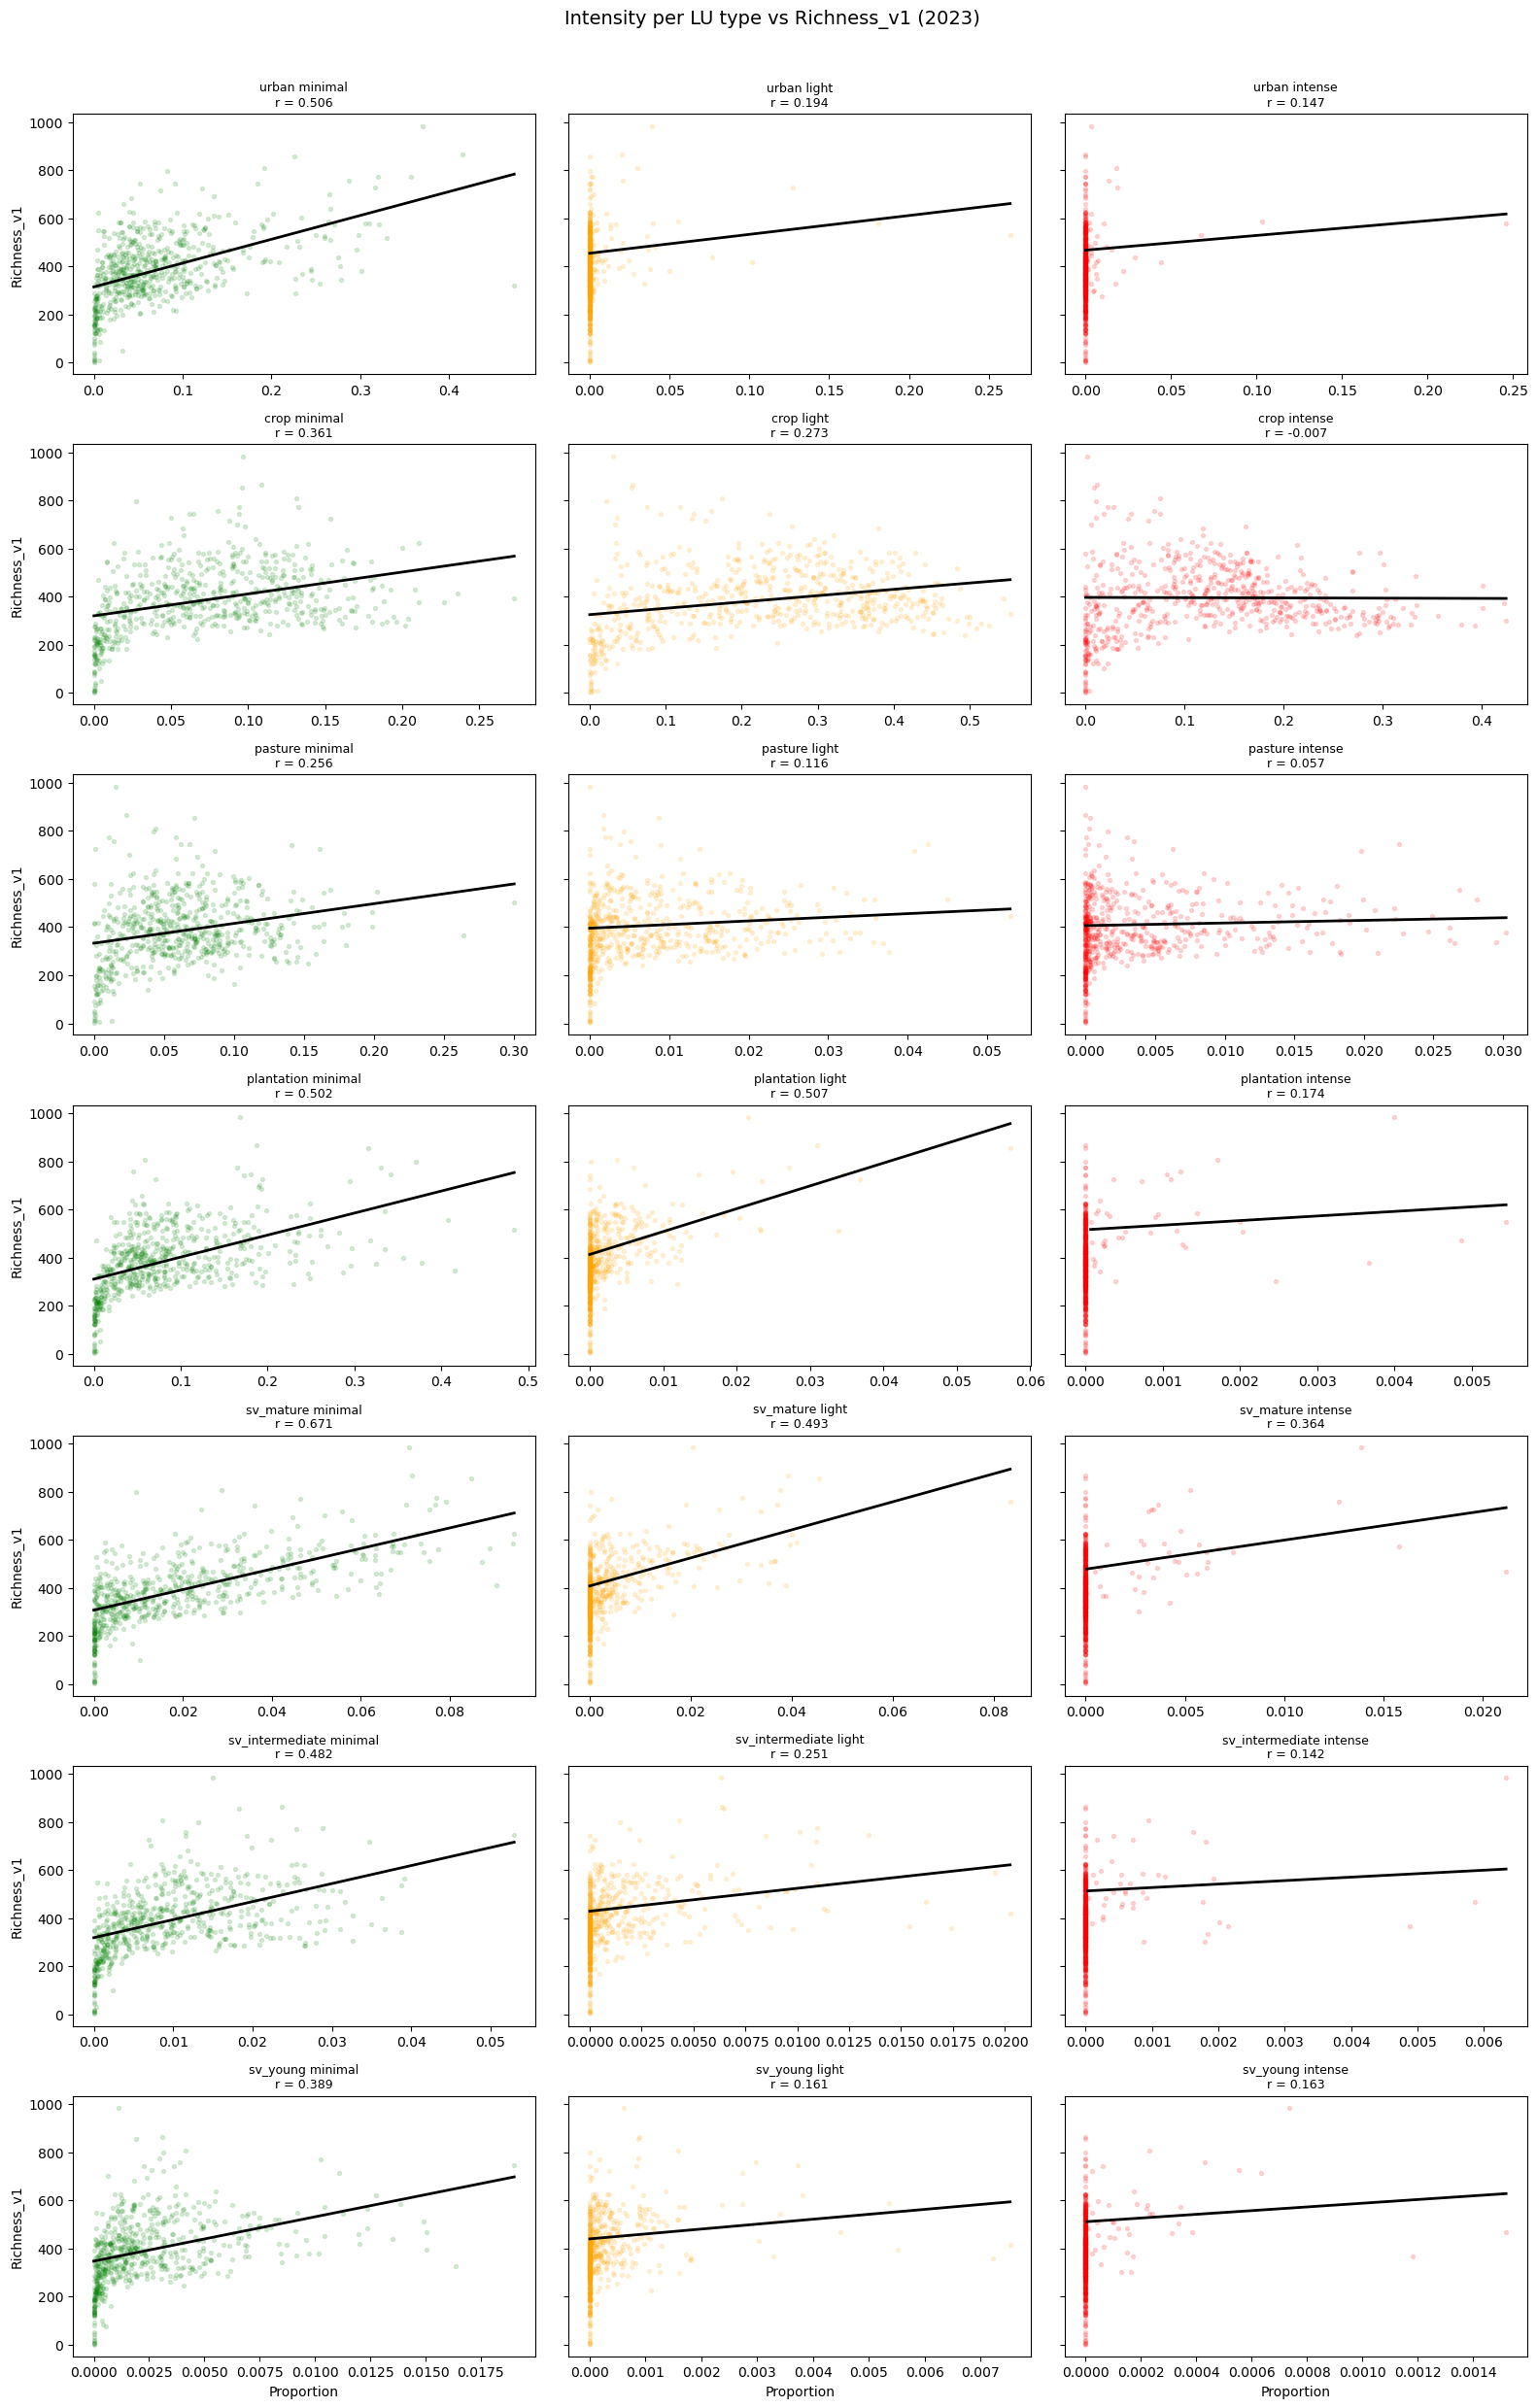


=== Correlation: intensity per LU type vs Richness (2023) ===

                 minimal_Richness_v1  minimal_Richness_v2  light_Richness_v1  light_Richness_v2  intense_Richness_v1  intense_Richness_v2
land_use                                                                                                                                 
urban                          0.508                0.512              0.174              0.168                0.112                0.111
crop                           0.389                0.437              0.273              0.328                0.115                0.172
pasture                        0.255                0.320              0.236              0.262                0.169                0.182
plantation                     0.505                0.501              0.489              0.434                0.215                0.174
sv_mature                      0.675                0.636              0.506              0.444             

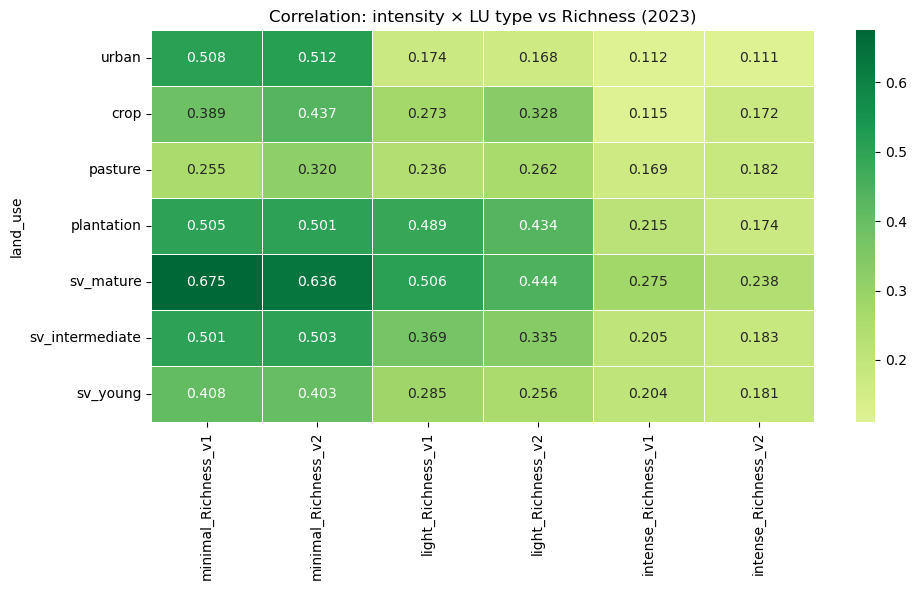

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

yr = "2023"
lu_types = ["urban", "crop", "pasture", "plantation",
            "sv_mature", "sv_intermediate", "sv_young"]

levels = ["minimal", "light", "intense"]
colors = {"minimal": "green", "light": "orange", "intense": "red"}

# ── 1) Scatter grid: per LU type, intensity vs Richness_v1 ──
fig, axes = plt.subplots(len(lu_types), 3, figsize=(16, 3.5 * len(lu_types)),
                         sharex=False, sharey=True)

for row_i, lu in enumerate(lu_types):
    for col_i, level in enumerate(levels):
        ax = axes[row_i, col_i]
        col = f"{lu}_{level}_{yr}"
        x = gridcell_dnk[col]
        y = pd.to_numeric(gridcell_dnk["Richness_v1"], errors="coerce")

        ax.scatter(x, y, alpha=0.15, s=8, color=colors[level])

        mask = x.notna() & y.notna() & (x > 0)
        if mask.sum() > 10:
            r = x[mask].corr(y[mask])
            z = np.polyfit(x[mask], y[mask], 1)
            xline = np.linspace(x[mask].min(), x[mask].max(), 100)
            ax.plot(xline, np.polyval(z, xline), color="black", lw=2)
            ax.set_title(f"{lu} {level}\nr = {r:.3f}", fontsize=9)
        else:
            ax.set_title(f"{lu} {level}\n(few data)", fontsize=9)

        if col_i == 0:
            ax.set_ylabel("Richness_v1")
        if row_i == len(lu_types) - 1:
            ax.set_xlabel("Proportion")

plt.suptitle(f"Intensity per LU type vs Richness_v1 ({yr})", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# ── 2) Summary correlation table ──
print(f"\n=== Correlation: intensity per LU type vs Richness ({yr}) ===\n")
rows = []
for lu in lu_types:
    row = {"land_use": lu}
    for level in levels:
        col = f"{lu}_{level}_{yr}"
        for rich in ["Richness_v1", "Richness_v2"]:
            x = gridcell_dnk[col]
            y = pd.to_numeric(gridcell_dnk[rich], errors="coerce")
            mask = x.notna() & y.notna()
            row[f"{level}_{rich}"] = x[mask].corr(y[mask])
    rows.append(row)

corr_table = pd.DataFrame(rows).set_index("land_use").round(3)
print(corr_table.to_string())


# ── 3) Heatmap of the correlation table ──
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr_table, annot=True, cmap="RdYlGn", center=0, fmt=".3f",
            ax=ax, linewidths=0.5)
ax.set_title(f"Correlation: intensity × LU type vs Richness ({yr})")
plt.tight_layout()
plt.show()



                 minimal_Richness_v1  minimal_Richness_v2  minimal_Rare-quartile  light_Richness_v1  light_Richness_v2  light_Rare-quartile  intense_Richness_v1  intense_Richness_v2  intense_Rare-quartile
land_use                                                                                                                                                                                                    
urban                          0.508                0.512                  0.232              0.174              0.168                0.094                0.112                0.111                  0.080
crop                           0.389                0.437                 -0.049              0.273              0.328               -0.136                0.115                0.172                 -0.208
pasture                        0.255                0.320                  0.106              0.236              0.262               -0.056                0.169                0.18

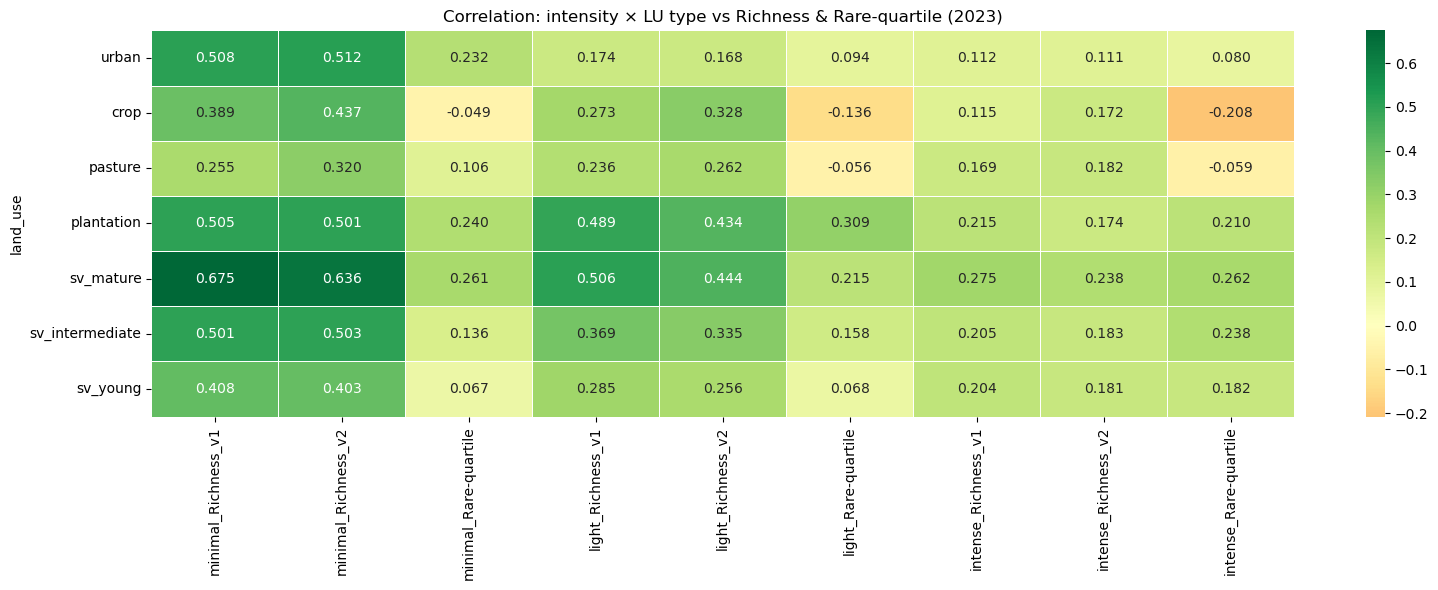

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

yr = "2023"
lu_types = ["urban", "crop", "pasture", "plantation",
            "sv_mature", "sv_intermediate", "sv_young"]
levels = ["minimal", "light", "intense"]
targets = ["Richness_v1", "Richness_v2", "Rare-quartile"]

# ── Build correlation table ──
rows = []
for lu in lu_types:
    row = {"land_use": lu}
    for level in levels:
        col = f"{lu}_{level}_{yr}"
        for target in targets:
            x = pd.to_numeric(gridcell_dnk[col], errors="coerce")
            y = pd.to_numeric(gridcell_dnk[target], errors="coerce")
            mask = x.notna() & y.notna()
            row[f"{level}_{target}"] = x[mask].corr(y[mask])
    rows.append(row)

corr_table = pd.DataFrame(rows).set_index("land_use").round(3)
print(corr_table.to_string())

# ── Heatmap ──
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(corr_table, annot=True, cmap="RdYlGn", center=0, fmt=".3f",
            ax=ax, linewidths=0.5)
ax.set_title(f"Correlation: intensity × LU type vs Richness & Rare-quartile ({yr})")
plt.tight_layout()
plt.show()

## LUI class mean BII value

In [35]:
lui_dnk = rxr.open_rasterio("/home/georg/data/LEON_P5_BII/BII_LU_layer/Land_use_map/v7/lu_intensity_dnk_2023_v7_remap.tif")
lui_nld = rxr.open_rasterio("/home/georg/data/LEON_P5_BII/BII_LU_layer/Land_use_map/v7/lu_intensity_nld_2023_v7_remap.tif")

bii_dnk = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/bii_world_dnk_2023_v7_100m.tif").squeeze()
bii_nld = rxr.open_rasterio(base / "BII_LU_layer/BII layers/v7/bii_world_nld_2023_v7_100m.tif").squeeze()

In [36]:
LUI_Group = {
    1: "Urban-min",
    2: "Urban-light",
    3: "Urban-int",

    4: "Cropland-min",
    5: "Cropland-light",
    6: "Cropland-int",

    7: "Pasture-min",
    8: "Pasture-light",
    9: "Pasture-int",

    10: "Plantation-min",
    11: "Plantation-light",
    12: "Plantation-int",

    13: "SV-Indeterminate-min",
    14: "SV-Indeterminate-light",
    15: "SV-Indeterminate-int",

    16: "SV-young",
    17: "SV-young",
    18: "SV-young",

    19: "SV-intermed-min",
    20: "SV-intermed-light",
    21: "SV-intermed-int",

    22: "SV-mature-min",
    23: "SV-mature-light",
    24: "SV-mature-int"
}


In [37]:
import numpy as np
import pandas as pd
from rasterio.enums import Resampling

# --- 1. Reproject LUI to match BII grid (nearest neighbour for categorical) ---
lui_dnk_repr = lui_dnk.squeeze().rio.reproject_match(bii_dnk, resampling=Resampling.nearest)
lui_nld_repr = lui_nld.squeeze().rio.reproject_match(bii_nld, resampling=Resampling.nearest)

# --- 2. Flatten to 1D numpy arrays ---
def to_flat(lui, bii):
    lui_vals = lui.values.ravel().astype(float)
    bii_vals = bii.values.ravel().astype(float)
    # mask nodata (typically 0 or negative in LUI, NaN in BII)
    mask = (lui_vals > 0) & np.isfinite(bii_vals) & np.isfinite(lui_vals)
    return lui_vals[mask].astype(int), bii_vals[mask]

lui_dnk_flat, bii_dnk_flat = to_flat(lui_dnk_repr, bii_dnk)
lui_nld_flat, bii_nld_flat = to_flat(lui_nld_repr, bii_nld)

# --- 3. Compute mean BII per class ---
rows = []
for cls, label in LUI_Group.items():
    mean_dnk = bii_dnk_flat[lui_dnk_flat == cls].mean() if (lui_dnk_flat == cls).any() else np.nan
    mean_nld = bii_nld_flat[lui_nld_flat == cls].mean() if (lui_nld_flat == cls).any() else np.nan
    rows.append({"Class": cls, "Label": label, "BII_mean_DNK": mean_dnk, "BII_mean_NLD": mean_nld})

df = pd.DataFrame(rows).set_index("Class")
df[["BII_mean_DNK", "BII_mean_NLD"]] = df[["BII_mean_DNK", "BII_mean_NLD"]].round(3)

print(df.to_string())

                        Label  BII_mean_DNK  BII_mean_NLD
Class                                                    
1                   Urban-min         0.613         0.626
2                 Urban-light         0.615         0.622
3                   Urban-int         0.414         0.415
4                Cropland-min         0.550         0.559
5              Cropland-light         0.433         0.442
6                Cropland-int         0.469         0.468
7                 Pasture-min         0.600         0.629
8               Pasture-light         0.535         0.506
9                 Pasture-int         0.652         0.647
10             Plantation-min         0.670         0.666
11           Plantation-light         0.646         0.632
12             Plantation-int         0.542         0.532
13       SV-Indeterminate-min         0.843         0.847
14     SV-Indeterminate-light         0.737         0.751
15       SV-Indeterminate-int         0.552         0.561
16            